# Section 6.3 — Category FEA profiles and multimodal errors

This notebook provides the descriptive FEA evidence for Section 6.3: raw category profiles, top-coefficient overlap, pairwise category-profile similarity, and exact confusion contrasts. It produces **four figures**: the full-channel category and confusion-difference heatmaps, plus their compact grouped alternatives. The final cells export four selected result tables and a self-contained Markdown report.

Run **all cells in order** from `emohevrdb-dfer/6_discussion/fea_analysis_2/` with Python, NumPy, pandas, and Matplotlib. No training or prior notebook execution is required. Input files are read directly. Human annotation-agreement results remain in `../fea_analysis/06_analyze_label_agreement_and_model_errors.ipynb`.

**Reading order:** settings and validation → shared calculations → category profiles and similarity → full-channel confusion results → compact figures and matching numbers → exports. Figure styles remain independently configurable beside each figure. Changing analysis settings requires rerunning all cells; changing only a style requires rerunning that figure and the report.

## 1. Evaluation settings and input paths

The attached notebook's evaluation settings are preserved: all splits for category profiles, test-only multimodal errors, top 8 error contrasts ranked by absolute difference, category top 20 with overlap cutoffs 10 and 20, and **no compact mean filtering** (`MIN_CATEGORY_MEAN=None`). `KEEP_ALL_AU_GROUPS=True` remains available when a threshold is enabled. Each setting occupies its own line with an explanation.


In [1]:
from pathlib import Path
import json
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT_OVERRIDE = None  # Set the repository root if the kernel starts outside the repository.
DATA_ROOT = Path('/workspace/datasets')  # Parent directory containing the original DFEA CSV folder.
DFEA_DIR_OVERRIDE = None  # Optionally set the exact directory containing the three split CSVs.
CATEGORY_SPLITS = ['train', 'validation', 'test']  # Splits included in the descriptive category figure.
TOP_N = 8  # Number of largest differences per confusion; preserved from the attached notebook.
RANK_ABSOLUTE_DELTA = True  # True ranks magnitude; False ranks signed increases.
RANK_BILATERAL = True  # Rank the defined L/R averages instead of their separate components.
MIN_RELATIVE_BASELINE = 0.01  # Suppress relative percentages below this correct-group mean.
SAVE_FIGURES = True  # Save all four figures as PDF and PNG.
SAVE_TABLES = True  # Save group counts and three selected contrast/component tables.

CATEGORY_TOP_N = 20  # Highest-mean individual coefficients displayed per category.
OVERLAP_TOP_N = 10  # Additional cutoff for top-coefficient overlap comparisons.
CATEGORY_PAIRS = [('Anger', 'Disgust'), ('Fear', 'Surprise')]  # Pairs inspected for top-coefficient overlap.
INSPECT_PAIR = ('Anger', 'Disgust')  # Pair inspected coefficient by coefficient; None skips the display.
N_COEFFICIENTS_TO_SHOW = 10  # Largest absolute coefficient differences displayed for INSPECT_PAIR.
MIN_CATEGORY_MEAN = None  # Retain groups exceeding this mean in any category; None disables filtering.
KEEP_ALL_AU_GROUPS = True  # Exempt AU-coded groups from an active mean threshold.
COMPACT_TOP_N = TOP_N  # Number of compact contrasts reported per confusion.
COMPACT_RANK_DISPLAYED_ONLY = True  # Rank only displayed groups; False considers all compact groups.
SUMMARY_FILENAME = 'section_6_3_summary.md'  # Markdown report written beside the figures.

CLASSES = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']  # Canonical class order used by the dataset and figures.
CONFUSIONS = [('Anger', 'Disgust'), ('Disgust', 'Happiness'), ('Surprise', 'Fear')]  # Exact source-to-target errors compared with correct source predictions.
SPLIT_FILES = {'train': 'training_set.csv', 'validation': 'validation_set.csv', 'test': 'test_set.csv'}  # Original raw FEA CSV filenames for each split.
EXPECTED_SIZES = {'train': 964, 'validation': 385, 'test': 378}  # Expected unique reenactments in each split.
EXPECTED_PARTICIPANTS = {'train': 20, 'validation': 8, 'test': 8}  # Expected unique participants in each split.

def require(condition, message):
    if not condition:
        raise ValueError(message)

# Locate the repository and common dataset layouts without searching the entire filesystem.
roots = [Path(REPO_ROOT_OVERRIDE)] if REPO_ROOT_OVERRIDE else [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next((p.resolve() for p in roots if (p / '6_discussion/multimodal-analysis').is_dir()), None)
require(REPO_ROOT is not None, 'Run from the repository or set REPO_ROOT_OVERRIDE.')
candidates = [Path(DFEA_DIR_OVERRIDE)] if DFEA_DIR_OVERRIDE else [
    DATA_ROOT, DATA_ROOT / 'emoji-hero-vr-db-dfea-as-csv', DATA_ROOT / 'emohevrdb/emoji-hero-vr-db-dfea-as-csv']
matches = {p.resolve() for p in candidates if all((p / name).is_file() for name in SPLIT_FILES.values())}
require(len(matches) == 1, 'Set DFEA_DIR_OVERRIDE to the directory containing the original DFEA CSVs.')
DFEA_DIR = matches.pop()
PREDICTION_CSV = REPO_ROOT / '6_discussion/multimodal-analysis/dynamic_test_predictions.csv'
OUTPUT_DIR = REPO_ROOT / '6_discussion/fea_analysis_2/outputs/section_6_3_focused'

mapping = json.loads((REPO_ROOT / '6_discussion/fea_analysis/data/facs_fea_mapping.json').read_text())
feature_mapping = pd.DataFrame(mapping['fea_to_facs']).sort_values('api_id_0based')
FEA_COLUMNS = feature_mapping['fea_name'].tolist()
AU_BY_FEATURE = feature_mapping.set_index('fea_name')['facs_code'].fillna('').to_dict()
paper_rows = sorted(mapping['paper_table']['au_to_fea'], key=lambda row: row['au_number'])
PAPER_FEATURES = [name.strip() for row in paper_rows for name in row['fea_names'].split('|') if name.strip()]
require(len(FEA_COLUMNS) == len(set(FEA_COLUMNS)) == 63, 'Expected 63 unique FEA channels.')
require(TOP_N > 0 and MIN_RELATIVE_BASELINE > 0, 'TOP_N and MIN_RELATIVE_BASELINE must be positive.')
require(bool(CATEGORY_SPLITS) and set(CATEGORY_SPLITS).issubset(SPLIT_FILES), 'Invalid category splits.')

require(COMPACT_TOP_N > 0, 'COMPACT_TOP_N must be positive.')


## 2. Load and validate the data

Average each raw FEA channel over the sequence's 30 steps. Validation checks split sizes, participant-disjoint splits, exact prediction joins, and the canonical multimodal result of **617/756 correct camera views**. Category profiles count each reenactment once; error analyses use the test camera-view predictions. Two views share one FEA sequence, so they are not independent FEA observations.


In [2]:
def read_sequence_means(split, filename):
    raw = pd.read_csv(DFEA_DIR / filename, dtype={'sequence_id': str})
    require(raw.columns.tolist() == ['sequence_id', 'timestamp', *FEA_COLUMNS, 'Label'], f'{split}: unexpected schema.')
    require(not raw.isna().any().any(), f'{split}: missing values.')
    values = raw[FEA_COLUMNS].to_numpy(dtype=float)
    require(np.isfinite(values).all() and values.min() >= -1e-8 and values.max() <= 1 + 1e-8, 'Invalid FEA values.')
    require(not raw.duplicated(['sequence_id', 'timestamp']).any(), f'{split}: duplicate sequence timestamps.')
    grouped = raw.groupby('sequence_id', sort=True)
    require(grouped.size().eq(30).all() and grouped['Label'].nunique().eq(1).all(), f'{split}: invalid sequences.')
    means = grouped[FEA_COLUMNS].mean().rename_axis('reenactment_id').reset_index()
    means['true_label_id'] = means['reenactment_id'].map(grouped['Label'].first())
    parts = means['reenactment_id'].str.split('-', expand=True)
    require(parts.shape[1] == 6 and not parts.isna().any().any(), f'{split}: invalid reenactment IDs.')
    parts = parts.apply(pd.to_numeric, errors='raise')
    require(np.equal(parts, np.floor(parts)).all().all(), f'{split}: noninteger ID components.')
    require(parts[5].eq(means['true_label_id']).all() and means['true_label_id'].isin(range(7)).all(), 'Label mismatch.')
    means['true_label'] = means['true_label_id'].map(dict(enumerate(CLASSES)))
    means['participant_id'] = parts[2].astype(int)
    means['split'] = split
    require(len(means) == EXPECTED_SIZES[split], f'{split}: unexpected reenactment count.')
    require(means['participant_id'].nunique() == EXPECTED_PARTICIPANTS[split], f'{split}: unexpected participant count.')
    return means

sequence_means = pd.concat([read_sequence_means(split, name) for split, name in SPLIT_FILES.items()], ignore_index=True)
require(sequence_means['reenactment_id'].is_unique, 'Reenactments overlap across splits.')
require(sequence_means.groupby('participant_id')['split'].nunique().eq(1).all(), 'Participants overlap across splits.')

columns = ['sample_id', 'reenactment_id', 'participant_id', 'camera_index', 'true_label_id', 'true_label', 'multimodal_pred']
predictions = pd.read_csv(PREDICTION_CSV, usecols=columns)
require(not predictions.isna().any().any() and predictions['sample_id'].is_unique, 'Missing or duplicate predictions.')
require(len(predictions) == 756 and predictions['multimodal_pred'].isin(CLASSES).all(), 'Unexpected prediction export.')
require(not predictions.duplicated(['reenactment_id', 'camera_index']).any(), 'Duplicate camera views.')
require(predictions.groupby('reenactment_id')['camera_index'].agg(set).eq({0, 1}).all(), 'Incomplete view pairs.')
require(predictions['sample_id'].eq(predictions['reenactment_id'] + '-' + predictions['camera_index'].astype(str)).all(),
        'Sample IDs do not match reenactment and camera IDs.')
test_means = sequence_means.loc[sequence_means['split'].eq('test')]
require(set(predictions['reenactment_id']) == set(test_means['reenactment_id']), 'Prediction/test IDs differ.')
test = predictions.merge(test_means, on='reenactment_id', validate='many_to_one', suffixes=('', '_fea'))
for column in ['true_label', 'true_label_id', 'participant_id']:
    require(test[column].eq(test[f'{column}_fea']).all(), f'Prediction/FEA {column} mismatch.')
test = test.drop(columns=['true_label_fea', 'true_label_id_fea', 'participant_id_fea'])
require(test.groupby('true_label').size().reindex(CLASSES).eq(108).all(), 'Test classes are not balanced.')
correct_count = test['true_label'].eq(test['multimodal_pred']).sum()
require(correct_count == 617, 'Predictions differ from the canonical 617/756 multimodal result.')

class_counts = pd.crosstab(sequence_means['true_label'], sequence_means['split']).reindex(CLASSES)
class_counts = class_counts[['train', 'validation', 'test']]
print(f"Loaded {len(sequence_means)} reenactments from {sequence_means['participant_id'].nunique()} participants.")
print(f"Multimodal test: {correct_count}/756 correct views ({100 * correct_count / 756:.2f}%), 378 reenactments, 8 participants.")
display(class_counts.rename_axis('Expression'))


Loaded 1727 reenactments from 36 participants.
Multimodal test: 617/756 correct views (81.61%), 378 reenactments, 8 participants.


split,train,validation,test
Expression,,,
Anger,66,55,54
Disgust,102,55,54
Fear,105,55,54
Happiness,191,55,54
Neutral,197,55,54
Sadness,131,55,54
Surprise,172,55,54


## 3. Shared calculations and plotting functions

`Correct` means true label = source and prediction = source; `Confused` means true label = source and prediction = the named target. Other errors are excluded. The primary contrast is **confused mean − correct mean**, weighting camera views equally.

The participant check deduplicates reenactments **within each group**, computes participant means, and averages the differences equally over participants present in both groups. `sign_reversal` identifies a direction change under this check. Relative change is `100 × delta_raw / correct_mean`; it is suppressed below `MIN_RELATIVE_BASELINE`.

The same calculation, ranking, and plotting functions are used for full-channel and compact analyses. They do not standardize coefficients. Exact ranking ties are resolved alphabetically.


In [3]:
def calculate_contrasts(correct, confused, features, source, target):
    """View-weighted means with a deduplicated, equal-shared-participant check."""
    correct_mean, confused_mean = correct[features].mean(), confused[features].mean()
    delta = confused_mean - correct_mean
    correct_by_participant = correct.drop_duplicates('reenactment_id').groupby('participant_id')[features].mean()
    confused_by_participant = confused.drop_duplicates('reenactment_id').groupby('participant_id')[features].mean()
    shared = correct_by_participant.index.intersection(confused_by_participant.index)
    shared_delta = (confused_by_participant.loc[shared] - correct_by_participant.loc[shared]).mean()
    result = pd.DataFrame({
        'correct_mean': correct_mean,
        'confused_mean': confused_mean,
        'delta_raw': delta,
        'relative_change_percent': 100 * delta / correct_mean.where(correct_mean >= MIN_RELATIVE_BASELINE),
        'shared_participant_delta': shared_delta,
    })
    result['sign_reversal'] = (delta * shared_delta < 0).astype('boolean').mask(shared_delta.isna())
    result['shared_participants'] = len(shared)
    result['source'], result['target'] = source, target
    return result.rename_axis('feature').reset_index()


def rank_contrasts(frame, features, top_n):
    """Select the top differences for each exact confusion, without duplicate components."""
    parts = []
    for source, target in CONFUSIONS:
        selected = frame.loc[frame['source'].eq(source) & frame['target'].eq(target) & frame['feature'].isin(features)].copy()
        selected['ranking_value'] = selected['delta_raw'].abs() if RANK_ABSOLUTE_DELTA else selected['delta_raw']
        selected = selected.sort_values(['ranking_value', 'feature'], ascending=[False, True]).head(top_n)
        selected['rank'] = np.arange(1, len(selected) + 1)
        parts.append(selected.drop(columns='ranking_value'))
    return pd.concat(parts, ignore_index=True)


def selected_components(selected, component_mapping):
    """Retrieve original-channel results behind each selected average or singleton."""
    parts = []
    for row in selected.itertuples():
        channels = component_mapping.get(row.feature, [row.feature])
        components = contrasts.loc[contrasts['source'].eq(row.source) & contrasts['target'].eq(row.target)
                                   & contrasts['feature'].isin(channels)].copy()
        parts.append(components.assign(rank=row.rank, selected_measure=row.feature))
    return pd.concat(parts, ignore_index=True)


result_columns = ['rank', 'feature', 'semantic_facs_code', 'correct_mean', 'confused_mean', 'delta_raw',
                  'relative_change_percent', 'shared_participant_delta', 'sign_reversal', 'shared_participants']
component_columns = ['rank', 'selected_measure', 'feature', 'correct_mean', 'confused_mean', 'delta_raw', 'relative_change_percent']


def display_contrasts(selected, components):
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 180):
        display(selected.set_index(['source', 'target'])[result_columns].round(4))
        display(components.set_index(['source', 'target'])[component_columns].round(4))
    for row in selected.loc[selected['sign_reversal'].fillna(False)].itertuples():
        print(f'Caution: {row.source} → {row.target}, {row.feature}: pooled Δ={row.delta_raw:+.3f}, '
              f'shared-participant Δ={row.shared_participant_delta:+.3f} ({row.shared_participants} participants).')


In [4]:
BILATERAL_STEMS = ['NoseWrinkler', 'LipTightener', 'CheekRaiser', 'LipCornerPuller', 'InnerBrowRaiser',
                   'OuterBrowRaiser', 'UpperLidRaiser', 'BrowLowerer', 'LidTightener', 'LipStretcher']
BILATERAL = {f'{stem}L/R': [f'{stem}L', f'{stem}R'] for stem in BILATERAL_STEMS}
MEASURES = FEA_COLUMNS + list(BILATERAL)
for name, channels in BILATERAL.items():
    test[name] = test[channels].mean(axis=1)

category_data = sequence_means.loc[sequence_means['split'].isin(CATEGORY_SPLITS)]
category_profile = category_data.groupby('true_label')[FEA_COLUMNS].mean().reindex(CLASSES)
category_counts = category_data.groupby('true_label').size().reindex(CLASSES)
require(category_profile.notna().all().all(), 'A category is absent from the selected splits.')

groups, result_parts, count_rows, delta_rows = {}, [], [], []
for source, target in CONFUSIONS:
    correct = test.loc[test['true_label'].eq(source) & test['multimodal_pred'].eq(source)]
    confused = test.loc[test['true_label'].eq(source) & test['multimodal_pred'].eq(target)]
    require(len(correct) > 0 and len(confused) > 0, f'Empty group for {source} -> {target}.')
    groups[(source, target)] = {'Correct': correct, 'Confused': confused}
    result = calculate_contrasts(correct, confused, MEASURES, source, target)
    result_parts.append(result)
    delta_rows.append(result.set_index('feature').loc[FEA_COLUMNS, 'delta_raw'])

    counts = {'source': source, 'target': target}
    for name, frame in [('correct', correct), ('confused', confused)]:
        counts[f'{name}_views'] = len(frame)
        counts[f'{name}_reenactments'] = frame['reenactment_id'].nunique()
        counts[f'{name}_participants'] = frame['participant_id'].nunique()
    counts['overlap_reenactments'] = len(set(correct['reenactment_id']) & set(confused['reenactment_id']))
    counts['shared_participants'] = int(result['shared_participants'].iloc[0])
    count_rows.append(counts)

contrasts = pd.concat(result_parts, ignore_index=True)
contrasts['semantic_facs_code'] = contrasts['feature'].map(lambda f: AU_BY_FEATURE.get(BILATERAL.get(f, [f])[0], ''))
delta_profiles = pd.DataFrame(delta_rows, index=[f'{s} → {t}' for s, t in CONFUSIONS])
group_counts = pd.DataFrame(count_rows)


In [5]:
def select_features(selection):
    if isinstance(selection, str):
        require(selection in ['all_63', 'paper_35'], 'Choose all_63, paper_35, or a list of channel names.')
        features = FEA_COLUMNS if selection == 'all_63' else PAPER_FEATURES
    else:
        features = list(selection)
    require(bool(features) and len(features) == len(set(features)) and set(features).issubset(FEA_COLUMNS), 'Invalid features.')
    return features

def draw_heatmap(ax, frame, row_labels, title, style, vmin, vmax, show_x=True, label_map=None):
    require(vmax > vmin, 'The upper color limit must exceed the lower color limit.')
    ax.set_facecolor(style.get('facecolor', 'white'))
    values = frame.to_numpy()
    image = ax.imshow(values, aspect='auto', interpolation='nearest', cmap=style['cmap'], vmin=vmin, vmax=vmax)
    if label_map is not None:
        labels = [label_map[f] for f in frame.columns]
    else:
        labels = [f'{f} ({AU_BY_FEATURE[f]})' if style['show_au_labels'] and AU_BY_FEATURE[f].startswith('AU') else f for f in frame.columns]
    ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=style['x_tick_rotation'], fontsize=style['x_tick_size'],
                  fontweight=style.get('tick_weight', 'normal'))
    ax.set_yticks(np.arange(len(row_labels)), labels=row_labels, fontsize=style['y_tick_size'], fontweight=style.get('tick_weight', 'normal'))
    ax.tick_params(axis='x', labelbottom=show_x, length=0, pad=style.get('x_tick_pad', 3.5))
    ax.tick_params(axis='y', length=0, pad=style.get('y_tick_pad', 8))
    for tick_label in ax.get_yticklabels():
        tick_label.set_horizontalalignment('right')
        tick_label.set_multialignment('right')
    if title:
        ax.set_title(title, loc=style.get('title_align', 'left'), fontsize=style['title_size'],
                     fontweight=style.get('title_weight', 'normal'), pad=style.get('title_pad', 8))
    ax.set_xlabel(style['x_label'] if show_x else '', fontsize=style['x_label_size'],
                  fontweight=style.get('label_weight', 'normal'), labelpad=style.get('x_label_pad', 4))
    ax.set_ylabel(style['y_label'], fontsize=style['y_label_size'],
                  fontweight=style.get('label_weight', 'normal'), labelpad=style.get('y_label_pad', 4))
    ax.grid(False, which='both')
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which='minor', color=style['grid_color'], linewidth=style['grid_width'])
    ax.tick_params(which='minor', bottom=False, top=False, left=False, right=False)
    for spine in ax.spines.values():
        spine.set_visible(style.get('show_spines', True))
    if style['annotate']:
        for row, col in np.ndindex(values.shape):
            luminance = np.dot(image.cmap(image.norm(values[row, col]))[:3], [0.299, 0.587, 0.114])
            ax.text(col, row, f'{values[row, col]:.2f}', ha='center', va='center', fontsize=style['annotation_size'],
                    color='black' if luminance > 0.55 else 'white')
    return image

def add_colorbar(fig, image, axes, style, label=True):
    colorbar = fig.colorbar(image, ax=axes, fraction=style.get('colorbar_fraction', 0.025), pad=style.get('colorbar_pad', 0.02))
    if label:
        colorbar.set_label(style['colorbar_label'], fontsize=style['colorbar_label_size'])
    colorbar.ax.tick_params(labelsize=style['colorbar_tick_size'])
    step = style.get('colorbar_tick_step')
    if step is not None:
        require(np.isfinite(step) and step > 0, 'The colorbar tick step must be positive or None.')
        start = np.ceil(image.norm.vmin / step) * step
        colorbar.set_ticks(np.arange(start, image.norm.vmax + 1e-9, step))

def show_and_save(fig, filename, style):
    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ['pdf', 'png']:
            fig.savefig(OUTPUT_DIR / f'{filename}.{extension}', dpi=style['save_dpi'], bbox_inches='tight',
                        pad_inches=style.get('save_pad_inches', 0.1), facecolor=fig.get_facecolor())
    plt.show()
    plt.close(fig)


figure_records = {}  # Capture the actual features and scales for the Markdown report.


def plot_category_profiles(frame, style, filename, label_map=None, append_splits=False):
    upper = style['vmax']
    if upper is None:
        upper = max(float(frame.to_numpy().max()), style['vmin'] + 1e-12)
    title = style['title'] + (' | ' + ' + '.join(CATEGORY_SPLITS) if append_splits else '')
    with plt.rc_context({'font.family': style['font_family'], 'figure.dpi': style['figure_dpi'], 'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none'}):
        fig, ax = plt.subplots(figsize=style['figsize'], layout='constrained', facecolor=style.get('facecolor', 'white'))
        row_format = style.get('category_row_format', '{category} (n={n})')
        labels = [row_format.format(category=category, n=category_counts[category]) for category in frame.index]
        image = draw_heatmap(ax, frame, labels, title, style, style['vmin'], upper, label_map=label_map)
        add_colorbar(fig, image, ax, style)
        show_and_save(fig, filename, style)
    figure_records[filename] = {'features': frame.columns.tolist(), 'cmap': style['cmap'],
                                'limits': [(style['vmin'], upper)], 'saved': SAVE_FIGURES}


def plot_delta_profiles(frame, style, filename, label_map=None):
    shared_limit = max(float(np.abs(frame.to_numpy()).max()), 1e-12)
    require(style['limit'] is None or style['limit'] > 0, 'The symmetric color limit must be positive.')
    limits = []
    label_position = style.get('confusion_label_position', 'title')
    require(label_position in ['row', 'title'], 'Use row or title for confusion labels.')
    with plt.rc_context({'font.family': style['font_family'], 'figure.dpi': style['figure_dpi'], 'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none'}):
        fig, axes = plt.subplots(len(frame), 1, figsize=style['figsize'], layout='constrained', sharex=True, squeeze=False,
                                 facecolor=style.get('facecolor', 'white'))
        axes = axes[:, 0]
        for index, (label, ax) in enumerate(zip(frame.index, axes)):
            panel = frame.loc[[label]]
            automatic_limit = shared_limit if style['shared_scale'] else max(float(np.abs(panel.to_numpy()).max()), 1e-12)
            limit = style['limit'] if style['limit'] is not None else automatic_limit
            # Put confusion names in the row labels for the caption-led paper style.
            row_label = label if label_position == 'row' else 'Confused − correct'
            panel_title = '' if label_position == 'row' else label
            image = draw_heatmap(ax, panel, [row_label], panel_title, style, -limit, limit,
                                 show_x=index == len(axes) - 1, label_map=label_map)
            limits.append((-limit, limit))
            if not style['shared_scale']:
                add_colorbar(fig, image, ax, style, label=index == len(axes) // 2)
        if style['shared_scale']:
            add_colorbar(fig, image, list(axes), style)
        show_and_save(fig, filename, style)
    figure_records[filename] = {'features': frame.columns.tolist(), 'cmap': style['cmap'],
                                'limits': limits, 'saved': SAVE_FIGURES}


## 4. Raw category profiles

These are **unstandardized means of sequence means**, with equal reenactment weight across `CATEGORY_SPLITS`. Labels show reenactment counts. `features` changes only this figure; category rankings and similarity calculations always use all 63 raw channels.

Each category figure supports `vmax=None` for its displayed maximum or a fixed upper limit such as `1.0`. Each delta figure supports an automatic or fixed symmetric `limit`, and `shared_scale=False` for a separate automatic scale per confusion. Colors are comparable between panels only when their limits match. Fixed limits can saturate colors without changing the values.


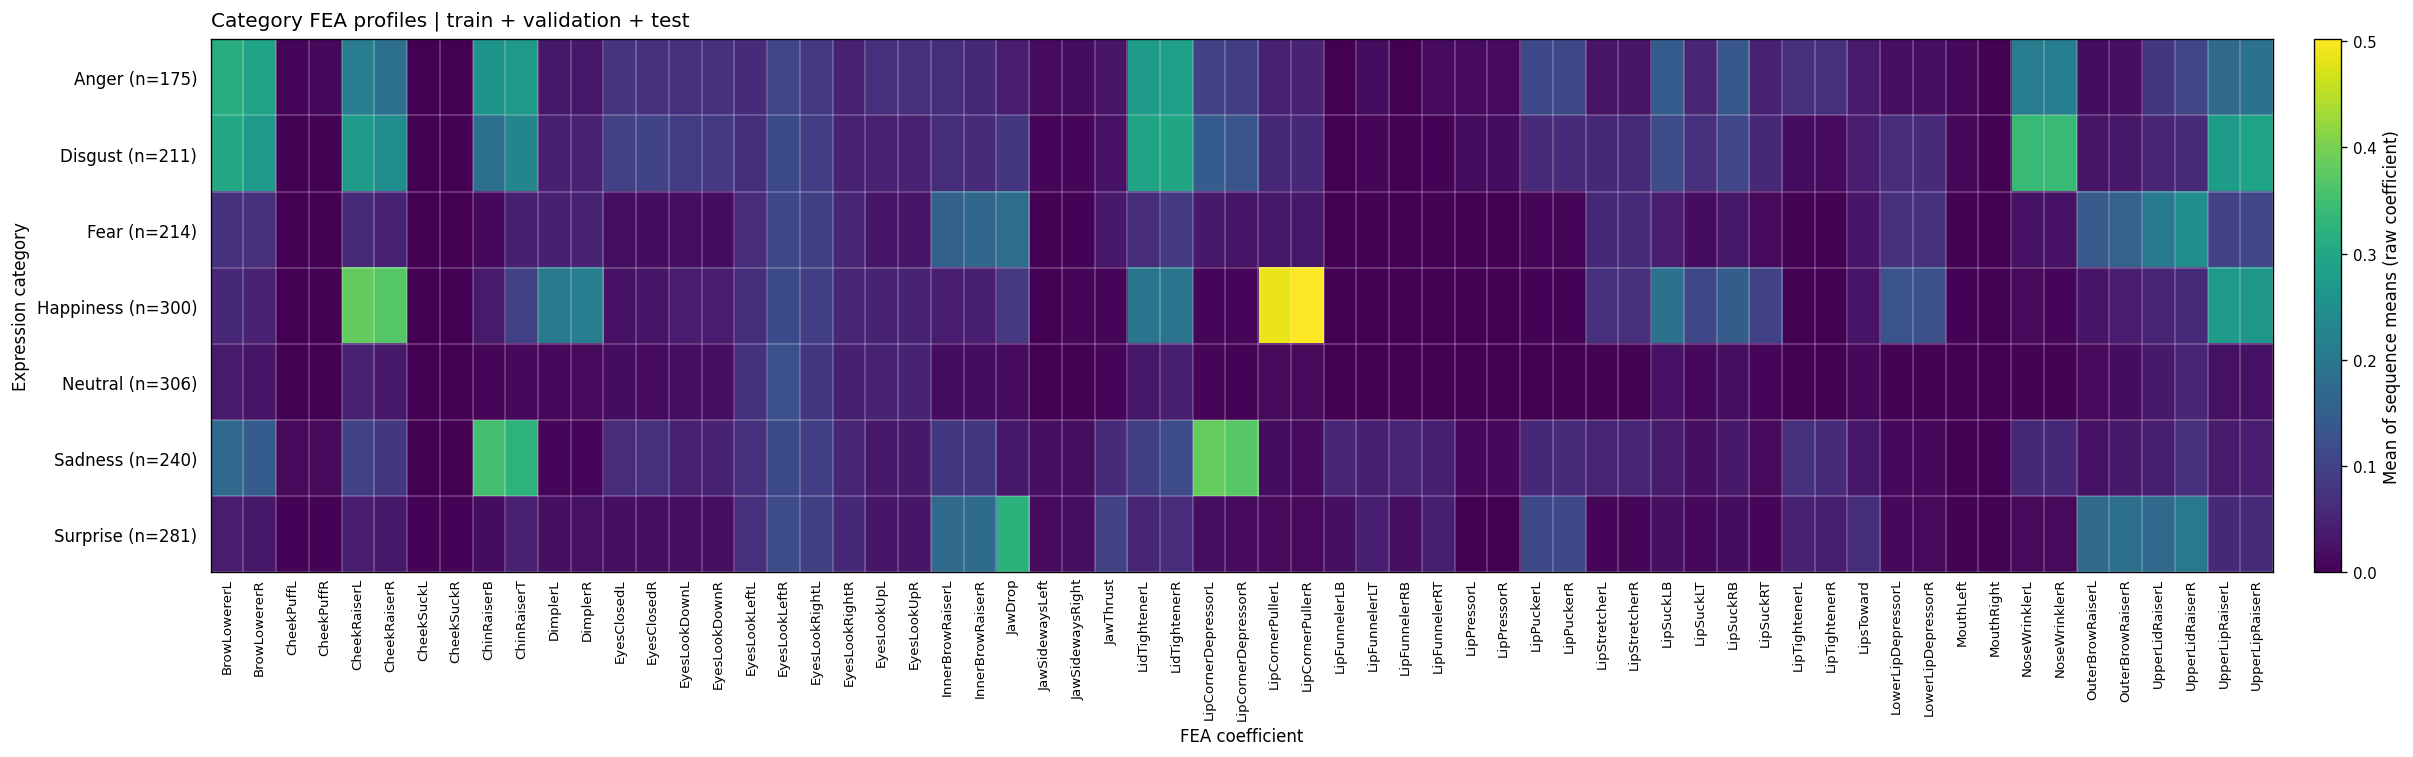

In [6]:
CATEGORY_STYLE = {
    'features': 'all_63',  # Choose all_63, paper_35, or a list of coefficient names.
    'figsize': (20, 6.2),  # Figure width and height in inches.
    'font_family': 'DejaVu Sans',  # Font for this figure only.
    'figure_dpi': 120,  # Resolution displayed in the notebook.
    'save_dpi': 300,  # Resolution of the exported PNG.
    'title': 'Category FEA profiles',  # Figure title; the selected splits are appended.
    'title_size': 12,  # Title font size in points.
    'x_label': 'FEA coefficient',  # X-axis title.
    'y_label': 'Expression category',  # Y-axis title.
    'x_label_size': 10,  # X-axis title font size.
    'y_label_size': 10,  # Y-axis title font size.
    'x_tick_size': 8,  # Coefficient label font size.
    'y_tick_size': 10,  # Category label font size.
    'x_tick_rotation': 90,  # Coefficient label rotation in degrees.
    'cmap': 'viridis',  # Sequential colormap for raw means.
    'vmin': 0.0,  # Lower color limit.
    'vmax': None,  # None uses the displayed maximum; a number fixes the upper limit.
    'show_au_labels': False,  # Append semantic FACS codes to coefficient names.
    'annotate': False,  # Print raw means inside cells.
    'annotation_size': 6,  # Font size for cell values.
    'grid_color': 'white',  # Cell boundary color.
    'grid_width': 0.25,  # Cell boundary width in points.
    'colorbar_label': 'Mean of sequence means (raw coefficient)',  # Colorbar title.
    'colorbar_label_size': 10,  # Colorbar title font size.
    'colorbar_tick_size': 9,  # Colorbar tick font size.
}

plot_category_profiles(category_profile[select_features(CATEGORY_STYLE['features'])], CATEGORY_STYLE,
                       '01_category_profiles_raw', append_splits=True)


### 4.1. Highest-mean coefficients and overlap

Rank all 63 individual channels by their category mean, then compare top-coefficient membership and ordering at the two configured cutoffs. **Overlap** = intersection size / cutoff; **Jaccard** = intersection size / union size. High mean activity does not by itself establish category specificity. The full rankings and shared-channel means remain available in `category_rankings` and `intersection_details`.


In [7]:
for n in [CATEGORY_TOP_N, OVERLAP_TOP_N]:
    if not isinstance(n, int) or not 1 <= n <= len(category_profile.columns):
        raise ValueError(f"Each cutoff must be an integer between 1 and {len(category_profile.columns)}.")

# Rank all individual coefficients; alphabetical ordering resolves exact ties.
category_rankings = {}
for category, means in category_profile.iterrows():
    ranked = means.rename('mean_sequence_mean').rename_axis('feature').reset_index()
    ranked = ranked.sort_values(['mean_sequence_mean', 'feature'], ascending=[False, True]).reset_index(drop=True)
    ranked.insert(0, 'rank', np.arange(1, len(ranked) + 1))
    category_rankings[category] = ranked

# Retain numeric results in a tidy table for further analysis.
top_fea_by_category = pd.concat(
    [ranked.head(CATEGORY_TOP_N).assign(category=category) for category, ranked in category_rankings.items()],
    ignore_index=True,
)[['category', 'rank', 'feature', 'mean_sequence_mean']]

# Display one column per category, with the coefficient and its raw mean.
top_fea_display = pd.DataFrame({
    category: [
        f"{row.feature} ({row.mean_sequence_mean:.3f})"
        for row in ranked.head(CATEGORY_TOP_N).itertuples()
    ]
    for category, ranked in category_rankings.items()
})
top_fea_display.index = pd.RangeIndex(1, CATEGORY_TOP_N + 1, name='Rank')

print(f"Top {CATEGORY_TOP_N} coefficients per category: coefficient (mean of sequence means)")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(top_fea_display)

# Compare membership and ordering at both requested cutoffs.
overlap_rows = []
intersection_rows = []

for first, second in CATEGORY_PAIRS:
    first_ranking = category_rankings[first].set_index('feature')
    second_ranking = category_rankings[second].set_index('feature')

    for n in sorted({CATEGORY_TOP_N, OVERLAP_TOP_N}):
        first_top = category_rankings[first].head(n)['feature'].tolist()
        second_top = category_rankings[second].head(n)['feature'].tolist()
        first_set, second_set = set(first_top), set(second_top)

        # List shared coefficients in their rank order in the first category.
        shared = [feature for feature in first_top if feature in second_set]
        union = first_set | second_set

        overlap_rows.append({
            'pair': f'{first} / {second}',
            'top_n': n,
            'shared_count': len(shared),
            'overlap_percent': 100 * len(shared) / n,
            'jaccard_percent': 100 * len(shared) / len(union),
            'identical_sets': first_set == second_set,
            'identical_order': first_top == second_top,
            'shared_coefficients': ', '.join(shared),
        })

        for feature in shared:
            intersection_rows.append({
                'pair': f'{first} / {second}',
                'top_n': n,
                'feature': feature,
                'first_category_rank': int(first_ranking.loc[feature, 'rank']),
                'second_category_rank': int(second_ranking.loc[feature, 'rank']),
                'first_category_mean': first_ranking.loc[feature, 'mean_sequence_mean'],
                'second_category_mean': second_ranking.loc[feature, 'mean_sequence_mean'],
            })

overlap_summary = pd.DataFrame(overlap_rows)
intersection_details = pd.DataFrame(intersection_rows)

print("\nOverlap = shared count / n; Jaccard = shared count / union size.")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(overlap_summary.round(1))


Top 20 coefficients per category: coefficient (mean of sequence means)


,Anger,Disgust,Fear,Happiness,Neutral,Sadness,Surprise
Rank,,,,,,,
1,BrowLowererL (0.312),NoseWrinklerR (0.339),UpperLidRaiserR (0.246),LipCornerPullerR (0.502),EyesLookLeftR (0.122),LipCornerDepressorL (0.383),JawDrop (0.322)
2,BrowLowererR (0.290),NoseWrinklerL (0.338),UpperLidRaiserL (0.205),LipCornerPullerL (0.488),EyesLookRightL (0.082),LipCornerDepressorR (0.372),UpperLidRaiserR (0.201)
3,LidTightenerR (0.282),BrowLowererL (0.302),JawDrop (0.178),CheekRaiserL (0.381),EyesLookLeftL (0.074),ChinRaiserB (0.351),OuterBrowRaiserR (0.186)
4,LidTightenerL (0.275),LidTightenerR (0.295),InnerBrowRaiserR (0.166),CheekRaiserR (0.370),UpperLidRaiserR (0.055),ChinRaiserT (0.325),InnerBrowRaiserR (0.178)
5,ChinRaiserT (0.271),LidTightenerL (0.293),OuterBrowRaiserR (0.158),UpperLipRaiserL (0.272),EyesLookUpR (0.049),BrowLowererL (0.171),OuterBrowRaiserL (0.173)
6,ChinRaiserB (0.259),UpperLipRaiserR (0.292),InnerBrowRaiserL (0.157),UpperLipRaiserR (0.266),EyesLookUpL (0.049),BrowLowererR (0.146),InnerBrowRaiserL (0.173)
7,NoseWrinklerR (0.214),CheekRaiserL (0.276),OuterBrowRaiserL (0.144),DimplerR (0.211),CheekRaiserL (0.045),LidTightenerR (0.115),UpperLidRaiserL (0.171)
8,NoseWrinklerL (0.212),UpperLipRaiserL (0.276),EyesLookLeftR (0.110),DimplerL (0.204),EyesLookRightR (0.044),EyesLookLeftR (0.114),EyesLookLeftR (0.115)
9,CheekRaiserL (0.212),BrowLowererR (0.270),UpperLipRaiserR (0.106),LidTightenerL (0.195),LidTightenerR (0.043),CheekRaiserL (0.097),LipPuckerR (0.111)



Overlap = shared count / n; Jaccard = shared count / union size.


,pair,top_n,shared_count,overlap_percent,jaccard_percent,identical_sets,identical_order,shared_coefficients
0,Anger / Disgust,10,8,80.0,66.7,False,False,"BrowLowererL, BrowLowererR, LidTightenerR, LidTightenerL, NoseWrinklerR, NoseWrinklerL, CheekRaiserL, UpperLipRaiserR"
1,Anger / Disgust,20,17,85.0,73.9,False,False,"BrowLowererL, BrowLowererR, LidTightenerR, LidTightenerL, ChinRaiserT, ChinRaiserB, NoseWrinklerR, NoseWrinklerL, CheekRaiserL, UpperLipRaiserR, CheekRaiserR, UpperLipRaiserL, LipSuckLB, LipSuckRB, EyesLookLeftR, LipCornerDepressorL, LipCornerDepressorR"
2,Fear / Surprise,10,8,80.0,66.7,False,False,"UpperLidRaiserR, UpperLidRaiserL, JawDrop, InnerBrowRaiserR, OuterBrowRaiserR, InnerBrowRaiserL, OuterBrowRaiserL, EyesLookLeftR"
3,Fear / Surprise,20,14,70.0,53.8,False,False,"UpperLidRaiserR, UpperLidRaiserL, JawDrop, InnerBrowRaiserR, OuterBrowRaiserR, InnerBrowRaiserL, OuterBrowRaiserL, EyesLookLeftR, UpperLipRaiserR, UpperLipRaiserL, EyesLookRightL, LidTightenerR, EyesLookLeftL, LidTightenerL"


### 4.2. Similarity of every category pair across all 63 channels

For each of the 21 unordered category pairs, calculate the per-channel signed difference and its absolute value, then average the 63 absolute differences:

$$d(a,b)=\frac{1}{63}\sum_{j=1}^{63}|\mu_{a,j}-\mu_{b,j}|.$$

A **smaller mean absolute difference means more similar category-average profiles**. Absolute differences prevent positive and negative changes from cancelling. This compares category means, not individual samples or within-category distributions. Every raw channel has equal weight; left and right channels remain separate. Compact grouping and filtering do not affect this ranking.

The table ranks all pairs. `category_pair_coefficient_differences` retains every coefficient comparison; `category_distance_matrix` retains the symmetric distance matrix. The optional inspected pair shows its largest differences; the signed column follows the table's first/second category order.


In [8]:
# Use all 63 raw coefficients, regardless of the heatmap grouping or filtering.
raw_profiles = category_profile.loc[CLASSES, FEA_COLUMNS]
require(raw_profiles.shape[1] == 63, 'Expected all 63 raw FEA coefficients.')
require(np.isfinite(raw_profiles.to_numpy()).all(), 'Category profiles contain missing or non-finite values.')

pair_rows = []
coefficient_rows = []

for first, second in combinations(CLASSES, 2):
    # Retain signed differences for interpretation, but use absolute differences for similarity.
    signed_difference = raw_profiles.loc[second] - raw_profiles.loc[first]
    absolute_difference = signed_difference.abs()

    pair_rows.append({
        'first_category': first,
        'second_category': second,
        'mean_absolute_difference': absolute_difference.mean(),
    })

    coefficient_rows.append(pd.DataFrame({
        'first_category': first,
        'second_category': second,
        'coefficient': FEA_COLUMNS,
        'first_category_mean': raw_profiles.loc[first].to_numpy(),
        'second_category_mean': raw_profiles.loc[second].to_numpy(),
        'signed_difference_second_minus_first': signed_difference.to_numpy(),
        'absolute_difference': absolute_difference.to_numpy(),
    }))

# Rank all 21 unique category pairs from most similar to least similar.
category_pair_ranking = pd.DataFrame(pair_rows).sort_values(
    ['mean_absolute_difference', 'first_category', 'second_category'],
    ascending=[True, True, True],
).reset_index(drop=True)
category_pair_ranking.insert(0, 'rank', np.arange(1, len(category_pair_ranking) + 1))

# Keep the full per-coefficient comparison available without printing all 1,323 rows.
category_pair_coefficient_differences = pd.concat(coefficient_rows, ignore_index=True)

# Build a symmetric comparison matrix; each category has zero distance from itself.
category_distance_matrix = pd.DataFrame(0.0, index=CLASSES, columns=CLASSES)
for row in category_pair_ranking.itertuples():
    category_distance_matrix.loc[row.first_category, row.second_category] = row.mean_absolute_difference
    category_distance_matrix.loc[row.second_category, row.first_category] = row.mean_absolute_difference

print('Category-profile similarity: lower mean absolute difference means greater similarity.')
print('Each coefficient receives equal weight; differences are in raw coefficient units.')

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 180):
    display(category_pair_ranking.round(5))

# Inspect individual coefficient differences for any category pair.

if INSPECT_PAIR is not None:
    first, second = INSPECT_PAIR
    require(first in CLASSES and second in CLASSES and first != second, 'Choose two distinct categories.')

    pair_details = category_pair_coefficient_differences.loc[
        (
            category_pair_coefficient_differences['first_category'].eq(first)
            & category_pair_coefficient_differences['second_category'].eq(second)
        )
        | (
            category_pair_coefficient_differences['first_category'].eq(second)
            & category_pair_coefficient_differences['second_category'].eq(first)
        )
    ].sort_values(['absolute_difference', 'coefficient'], ascending=[False, True])

    print(f'Largest coefficient differences for {first} / {second}:')
    display(pair_details.head(N_COEFFICIENTS_TO_SHOW).round(5))


Category-profile similarity: lower mean absolute difference means greater similarity.
Each coefficient receives equal weight; differences are in raw coefficient units.


,rank,first_category,second_category,mean_absolute_difference
0,1,Fear,Surprise,0.02409
1,2,Anger,Disgust,0.02672
2,3,Fear,Neutral,0.03357
3,4,Neutral,Surprise,0.03526
4,5,Neutral,Sadness,0.05101
5,6,Anger,Sadness,0.05159
6,7,Sadness,Surprise,0.05751
7,8,Fear,Sadness,0.05770
8,9,Disgust,Sadness,0.06277
9,10,Happiness,Neutral,0.06653


Largest coefficient differences for Anger / Disgust:


,first_category,second_category,coefficient,first_category_mean,second_category_mean,signed_difference_second_minus_first,absolute_difference
55,Anger,Disgust,NoseWrinklerL,0.21238,0.33790,0.12552,0.12552
56,Anger,Disgust,NoseWrinklerR,0.21381,0.33918,0.12537,0.12537
62,Anger,Disgust,UpperLipRaiserR,0.18627,0.29184,0.10557,0.10557
61,Anger,Disgust,UpperLipRaiserL,0.17269,0.27599,0.10330,0.10330
8,Anger,Disgust,ChinRaiserB,0.25892,0.18395,-0.07496,0.07496
4,Anger,Disgust,CheekRaiserL,0.21204,0.27620,0.06416,0.06416
5,Anger,Disgust,CheekRaiserR,0.18246,0.24324,0.06078,0.06078
48,Anger,Disgust,LipTightenerL,0.07105,0.01677,-0.05428,0.05428
49,Anger,Disgust,LipTightenerR,0.06755,0.01462,-0.05293,0.05293
40,Anger,Disgust,LipPuckerL,0.11100,0.06204,-0.04896,0.04896


## 5. Exact multimodal confusions: full-channel results

The three panels compare correct source-category cases with the exact named error. Positive deltas indicate larger coefficients in confused cases; negative deltas indicate smaller coefficients. Primary error means are view-weighted. The counts below expose repeated views, overlapping reenactments, and participant coverage. These contrasts do not compare confused cases with correctly classified target-category cases.


In [9]:
display(group_counts.set_index(['source', 'target']))


,,correct_views,correct_reenactments,correct_participants,confused_views,confused_reenactments,confused_participants,overlap_reenactments,shared_participants
source,target,,,,,,,,
Anger,Disgust,60,34,7,44,26,7,8,6
Disgust,Happiness,72,39,8,20,11,3,2,3
Surprise,Fear,87,48,8,20,14,5,8,5


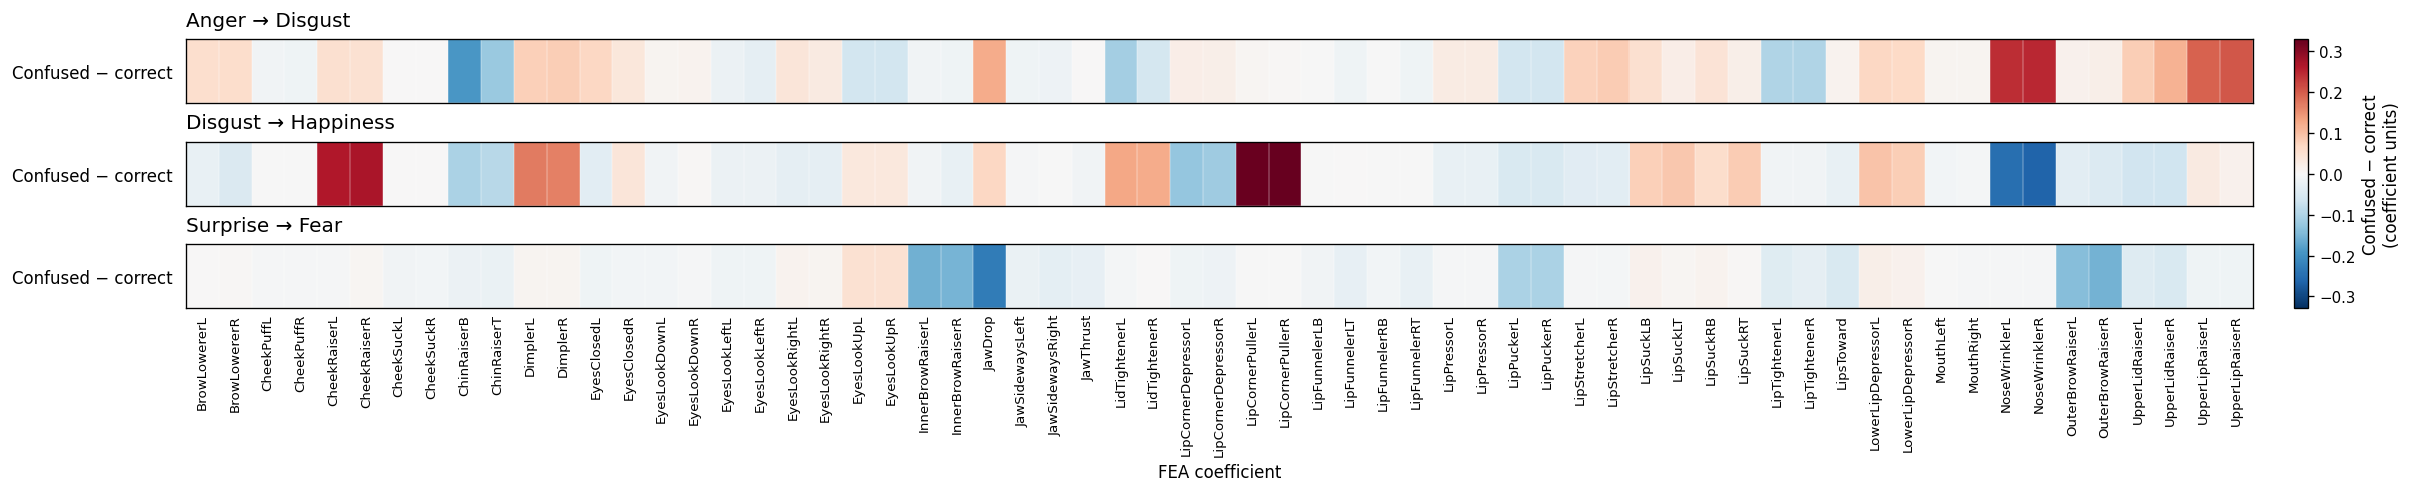

In [10]:
DELTA_STYLE = {
    'features': 'all_63',  # Choose all_63, paper_35, or a list independently of the category figure.
    'figsize': (20, 4),  # Combined figure width and height in inches.
    'font_family': 'DejaVu Sans',  # Font for this figure only.
    'figure_dpi': 120,  # Resolution displayed in the notebook.
    'save_dpi': 300,  # Resolution of the exported PNG.
    'title_size': 12,  # Font size of each confusion title.
    'x_label': 'FEA coefficient',  # Shared x-axis title.
    'y_label': '',  # Optional y-axis title for each panel.
    'x_label_size': 10,  # X-axis title font size.
    'y_label_size': 10,  # Y-axis title font size.
    'x_tick_size': 8,  # Coefficient label font size.
    'y_tick_size': 10,  # Row label font size.
    'x_tick_rotation': 90,  # Coefficient label rotation in degrees.
    'cmap': 'RdBu_r',  # Red indicates increases; blue indicates decreases.
    'limit': None,  # Symmetric +/- limit; None derives it from displayed differences.
    'shared_scale': True,  # Use one scale and colorbar for all panels.
    'show_au_labels': False,  # Append semantic FACS codes to coefficient names.
    'annotate': False,  # Print signed differences inside cells.
    'annotation_size': 6,  # Font size for cell values.
    'grid_color': 'white',  # Cell boundary color.
    'grid_width': 0.25,  # Cell boundary width in points.
    'colorbar_label': 'Confused − correct' + chr(10) + '(coefficient units)',  # Colorbar title.
    'colorbar_label_size': 10,  # Colorbar title font size.
    'colorbar_tick_size': 9,  # Colorbar tick font size.
}

plot_delta_profiles(delta_profiles[select_features(DELTA_STYLE['features'])], DELTA_STYLE, '02_confused_minus_correct')


### 5.1. Baseline numbers for Section 6.3

`RANK_BILATERAL=True` replaces the constituents of the original **10 L/R pairs** with their averages when ranking; other coefficients stay individual. This preserves the baseline analysis. Section 6.3 below instead uses **all compact groups**, exactly matching the compact heatmaps.

The first table reports the selected differences and participant checks; the second exposes their individual components. Quote raw deltas as **coefficient units**, not unqualified percentage points. Relative changes are percentages of the correct-group mean. Rankings are exploratory: neither a large difference nor an AU crosswalk label establishes significance, model reliance, or causation.


In [11]:
bilateral_channels = {channel for channels in BILATERAL.values() for channel in channels}
ranking_measures = [f for f in FEA_COLUMNS if f not in bilateral_channels] + list(BILATERAL) if RANK_BILATERAL else FEA_COLUMNS
selected_contrasts = rank_contrasts(contrasts, ranking_measures, TOP_N)
selected_channels = selected_components(selected_contrasts, BILATERAL)
display_contrasts(selected_contrasts, selected_channels)


rank              feature semantic_facs_code  correct_mean  confused_mean  delta_raw  relative_change_percent  shared_participant_delta  sign_reversal  \
source   target                                                                                                                                                              
Anger    Disgust       1      NoseWrinklerL/R                AU9        0.1439         0.3887     0.2448                 170.1670                    0.0201          False   
         Disgust       2      UpperLipRaiserR               AU10        0.1795         0.3826     0.2031                 113.1788                    0.0159          False   
         Disgust       3      UpperLipRaiserL               AU10        0.1671         0.3611     0.1940                 116.1078                    0.0148          False   
         Disgust       4          ChinRaiserB               AU17        0.3490         0.1566    -0.1924                 -55.1269                   -0.1205          False   
         Disgust       5          ChinRaiserT               AU17        0.3568         0.2340    -0.1228                 -34.4207                   -0.1009          False   
         Disgust       6              JawDrop               AU26        0.0200         0.1416     0.1216                 606.7207                    0.0093          False   
         Disgust       7      LipTightenerL/R               AU23        0.1160         0.0169    -0.0991                 -85.4708                    0.0112           True   
         Disgust       8    UpperLidRaiserL/R                AU5        0.0972         0.1945     0.0972                  99.9543                    0.0366          False   
Disgust  Happiness     1   LipCornerPullerL/R               AU12        0.0710         0.3974     0.3264                 459.4986                    0.2268          False   
         Happiness     2       CheekRaiserL/R                AU6        0.2534         0.5195     0.2661                 105.0344                    0.0930          False   
         Happiness     3      NoseWrinklerL/R                AU9        0.3276         0.0717    -0.2559                 -78.1192                   -0.1560          False   
         Happiness     4             DimplerL               AU14        0.0795         0.2499     0.1704                 214.1923                    0.1414          False   
         Happiness     5             DimplerR               AU14        0.0799         0.2463     0.1664                 208.3315                    0.1390          False   
         Happiness     6  LipCornerDepressorL               AU15        0.1432         0.0159    -0.1273                 -88.8958                   -0.0204          False   
         Happiness     7      LidTightenerL/R                AU7        0.2844         0.4095     0.1251                  43.9898                    0.1656          False   
         Happiness     8  LipCornerDepressorR               AU15        0.1213         0.0047    -0.1165                 -96.0998                   -0.0199          False   
Surprise Fear          1              JawDrop               AU26        0.4362         0.2075    -0.2287                 -52.4323                   -0.0597          False   
         Fear          2   InnerBrowRaiserL/R                AU1        0.3269         0.1706    -0.1563                 -47.8130                   -0.0738          False   
         Fear          3   OuterBrowRaiserL/R                AU2        0.3332         0.1864    -0.1468                 -44.0579                   -0.0805          False   
         Fear          4           LipPuckerR               AU18        0.1295         0.0265    -0.1030                 -79.5121                   -0.1041          False   
         Fear          5           LipPuckerL               AU18        0.1277         0.0247    -0.1030                 -80.6294                   -0.1025          False   
         Fear     

rank     selected_measure              feature  correct_mean  confused_mean  delta_raw  relative_change_percent
source   target                                                                                                                    
Anger    Disgust       1      NoseWrinklerL/R        NoseWrinklerL        0.1443         0.3873     0.2430                 168.3753
         Disgust       1      NoseWrinklerL/R        NoseWrinklerR        0.1434         0.3901     0.2467                 171.9693
         Disgust       2      UpperLipRaiserR      UpperLipRaiserR        0.1795         0.3826     0.2031                 113.1788
         Disgust       3      UpperLipRaiserL      UpperLipRaiserL        0.1671         0.3611     0.1940                 116.1078
         Disgust       4          ChinRaiserB          ChinRaiserB        0.3490         0.1566    -0.1924                 -55.1269
         Disgust       5          ChinRaiserT          ChinRaiserT        0.3568         0.2340    -0.1228                 -34.4207
         Disgust       6              JawDrop              JawDrop        0.0200         0.1416     0.1216                 606.7207
         Disgust       7      LipTightenerL/R        LipTightenerL        0.1171         0.0178    -0.0993                 -84.8030
         Disgust       7      LipTightenerL/R        LipTightenerR        0.1149         0.0159    -0.0990                 -86.1510
         Disgust       8    UpperLidRaiserL/R      UpperLidRaiserL        0.0900         0.1712     0.0811                  90.1454
         Disgust       8    UpperLidRaiserL/R      UpperLidRaiserR        0.1045         0.2177     0.1133                 108.4052
Disgust  Happiness     1   LipCornerPullerL/R     LipCornerPullerL        0.0706         0.3948     0.3241                 458.8386
         Happiness     1   LipCornerPullerL/R     LipCornerPullerR        0.0714         0.4001     0.3287                 460.1513
         Happiness     2       CheekRaiserL/R         CheekRaiserL        0.2682         0.5309     0.2627                  97.9257
         Happiness     2       CheekRaiserL/R         CheekRaiserR        0.2385         0.5080     0.2695                 113.0309
         Happiness     3      NoseWrinklerL/R        NoseWrinklerL        0.3257         0.0781    -0.2477                 -76.0294
         Happiness     3      NoseWrinklerL/R        NoseWrinklerR        0.3294         0.0653    -0.2641                 -80.1856
         Happiness     4             DimplerL             DimplerL        0.0795         0.2499     0.1704                 214.1923
         Happiness     5             DimplerR             DimplerR        0.0799         0.2463     0.1664                 208.3315
         Happiness     6  LipCornerDepressorL  LipCornerDepressorL        0.1432         0.0159    -0.1273                 -88.8958
         Happiness     7      LidTightenerL/R        LidTightenerL        0.2901         0.4178     0.1277                  44.0270
         Happiness     7      LidTightenerL/R        LidTightenerR        0.2787         0.4012     0.1225                  43.9511
         Happiness     8  LipCornerDepressorR  LipCornerDepressorR        0.1213         0.0047    -0.1165                 -96.0998
Surprise Fear          1              JawDrop              JawDrop        0.4362         0.2075    -0.2287                 -52.4323
         Fear          2   InnerBrowRaiserL/R     InnerBrowRaiserL        0.3252         0.1663    -0.1589                 -48.8592
         Fear          2   InnerBrowRaiserL/R     InnerBrowRaiserR        0.3286         0.1749    -0.1537                 -46.7776
         Fear          3   OuterBrowRaiserL/R     OuterBrowRaiserL        0.3269         0.1878    -0.1391                 -42.5558
         Fear          3   OuterBrowRaiserL/R     OuterBrowRaiserR        0.3394         0.1850    -0.1545                 -45.5046
         Fear          4           LipPuckerR           LipP

Caution: Anger → Disgust, LipTightenerL/R: pooled Δ=-0.099, shared-participant Δ=+0.011 (6 participants).
Caution: Surprise → Fear, EyesLookUpR: pooled Δ=+0.051, shared-participant Δ=-0.015 (5 participants).
Caution: Surprise → Fear, EyesLookUpL: pooled Δ=+0.050, shared-participant Δ=-0.015 (5 participants).


## 6. Compact alternatives: explicit grouping and optional filtering

Each group is the **equal average of its constituent sequence-mean coefficients**. Matching L/R movements are combined; `ChinRaiserT/B` averages its two channels; `LipFunnelerLT/LB/RT/RB` and `LipSuckLT/LB/RT/RB` average all four listed channels. Opposing directions remain separate, including `JawSidewaysLeft/Right` and `MouthLeft/Right`. AU suffixes follow coefficient names, for example `LipSuckLT/LB/RT/RB (AU28)`.

A threshold-tested group is retained if its mean is **strictly greater than `MIN_CATEGORY_MEAN` in at least one category**. `KEEP_ALL_AU_GROUPS=True` exempts AU-coded groups from that threshold; AD and eye-position codes do not qualify. `MIN_CATEGORY_MEAN=None` currently retains every group. Both compact figures use the same columns and order. This presentation filter does not establish that excluded movements are uninformative for errors, and does not change the 63-channel analyses.

The mapping below records every constituent and retention decision. Semantic FACS codes are crosswalk labels, not validated AU measurements.


In [12]:
# Explicit groups preserve movement direction and show exactly which channels are averaged.
COMPACT_GROUPS = {
    'BrowLowererL/R': ['BrowLowererL', 'BrowLowererR'],
    'CheekPuffL/R': ['CheekPuffL', 'CheekPuffR'],
    'CheekRaiserL/R': ['CheekRaiserL', 'CheekRaiserR'],
    'CheekSuckL/R': ['CheekSuckL', 'CheekSuckR'],
    'ChinRaiserT/B': ['ChinRaiserT', 'ChinRaiserB'],
    'DimplerL/R': ['DimplerL', 'DimplerR'],
    'EyesClosedL/R': ['EyesClosedL', 'EyesClosedR'],
    'EyesLookDownL/R': ['EyesLookDownL', 'EyesLookDownR'],
    'EyesLookLeftL/R': ['EyesLookLeftL', 'EyesLookLeftR'],
    'EyesLookRightL/R': ['EyesLookRightL', 'EyesLookRightR'],
    'EyesLookUpL/R': ['EyesLookUpL', 'EyesLookUpR'],
    'InnerBrowRaiserL/R': ['InnerBrowRaiserL', 'InnerBrowRaiserR'],
    'JawDrop': ['JawDrop'],
    'JawSidewaysLeft': ['JawSidewaysLeft'],
    'JawSidewaysRight': ['JawSidewaysRight'],
    'JawThrust': ['JawThrust'],
    'LidTightenerL/R': ['LidTightenerL', 'LidTightenerR'],
    'LipCornerDepressorL/R': ['LipCornerDepressorL', 'LipCornerDepressorR'],
    'LipCornerPullerL/R': ['LipCornerPullerL', 'LipCornerPullerR'],
    'LipFunnelerLT/LB/RT/RB': ['LipFunnelerLT', 'LipFunnelerLB', 'LipFunnelerRT', 'LipFunnelerRB'],
    'LipPressorL/R': ['LipPressorL', 'LipPressorR'],
    'LipPuckerL/R': ['LipPuckerL', 'LipPuckerR'],
    'LipStretcherL/R': ['LipStretcherL', 'LipStretcherR'],
    'LipSuckLT/LB/RT/RB': ['LipSuckLT', 'LipSuckLB', 'LipSuckRT', 'LipSuckRB'],
    'LipTightenerL/R': ['LipTightenerL', 'LipTightenerR'],
    'LipsToward': ['LipsToward'],
    'LowerLipDepressorL/R': ['LowerLipDepressorL', 'LowerLipDepressorR'],
    'MouthLeft': ['MouthLeft'],
    'MouthRight': ['MouthRight'],
    'NoseWrinklerL/R': ['NoseWrinklerL', 'NoseWrinklerR'],
    'OuterBrowRaiserL/R': ['OuterBrowRaiserL', 'OuterBrowRaiserR'],
    'UpperLidRaiserL/R': ['UpperLidRaiserL', 'UpperLidRaiserR'],
    'UpperLipRaiserL/R': ['UpperLipRaiserL', 'UpperLipRaiserR'],
}
members = [channel for channels in COMPACT_GROUPS.values() for channel in channels]
require(len(members) == len(set(members)) and set(members) == set(FEA_COLUMNS), 'Each raw channel must occur in exactly one group.')
COMPACT_FACS_CODES = {}
for name, channels in COMPACT_GROUPS.items():
    codes = {AU_BY_FEATURE[channel] for channel in channels}
    require(len(codes) == 1, f'{name}: constituents must have one shared semantic FACS code.')
    COMPACT_FACS_CODES[name] = codes.pop()

def grouped_sequence_means(frame):
    return pd.DataFrame({name: frame[channels].mean(axis=1) for name, channels in COMPACT_GROUPS.items()}, index=frame.index)

def compact_feature_labels(style):
    return {name: f'{name} ({COMPACT_FACS_CODES[name]})' if style['show_au_labels'] and COMPACT_FACS_CODES[name].startswith('AU')
            else name for name in COMPACT_FEATURES}

compact_category_profile = grouped_sequence_means(category_data).groupby(category_data['true_label']).mean().reindex(CLASSES)
# Compute compact contrasts once; their deltas also supply the compact heatmaps.
compact_result_parts = []
for source, target in CONFUSIONS:
    frames = []
    for name in ['Correct', 'Confused']:
        frame = groups[(source, target)][name]
        frames.append(pd.concat([frame[['reenactment_id', 'participant_id']], grouped_sequence_means(frame)], axis=1))
    compact_result_parts.append(calculate_contrasts(*frames, list(COMPACT_GROUPS), source, target))
compact_contrasts = pd.concat(compact_result_parts, ignore_index=True)
compact_contrasts['semantic_facs_code'] = compact_contrasts['feature'].map(COMPACT_FACS_CODES)
compact_contrasts['channels_averaged'] = compact_contrasts['feature'].map(lambda name: ', '.join(COMPACT_GROUPS[name]))
compact_delta_profiles = pd.DataFrame([
    compact_contrasts.loc[compact_contrasts['source'].eq(source) & compact_contrasts['target'].eq(target)]
    .set_index('feature')['delta_raw'].reindex(COMPACT_GROUPS)
    for source, target in CONFUSIONS
], index=delta_profiles.index)

maximum_category_means = compact_category_profile.max(axis=0)
if MIN_CATEGORY_MEAN is not None:
    require(np.isfinite(MIN_CATEGORY_MEAN) and 0 <= MIN_CATEGORY_MEAN <= 1, 'Use a threshold in [0, 1], or None.')
require(isinstance(KEEP_ALL_AU_GROUPS, bool), 'KEEP_ALL_AU_GROUPS must be True or False.')
is_au_group = pd.Series({name: code.startswith('AU') for name, code in COMPACT_FACS_CODES.items()})
passes_mean_filter = maximum_category_means.gt(MIN_CATEGORY_MEAN) if MIN_CATEGORY_MEAN is not None else maximum_category_means.notna()
retained = passes_mean_filter | (is_au_group & KEEP_ALL_AU_GROUPS)
COMPACT_FEATURES = maximum_category_means.index[retained].tolist()
require(bool(COMPACT_FEATURES), 'No groups survived. Lower MIN_CATEGORY_MEAN, set it to None, or enable KEEP_ALL_AU_GROUPS.')

def compact_retention_reason(name):
    if MIN_CATEGORY_MEAN is None:
        return 'filter disabled'
    if KEEP_ALL_AU_GROUPS and is_au_group[name]:
        return 'AU group retained by mode'
    return 'above threshold' if passes_mean_filter[name] else 'at or below threshold'
compact_mapping = pd.DataFrame([
    {'group': name, 'semantic_facs_code': COMPACT_FACS_CODES[name], 'channels_averaged': ', '.join(channels),
     'n_channels': len(channels), 'maximum_category_mean': maximum_category_means[name], 'is_au': bool(is_au_group[name]),
     'passes_mean_filter': bool(passes_mean_filter[name]), 'retained': bool(retained[name]), 'retention_reason': compact_retention_reason(name)}
    for name, channels in COMPACT_GROUPS.items()
])
print(f'{len(FEA_COLUMNS)} raw channels → {len(COMPACT_GROUPS)} groups → {len(COMPACT_FEATURES)} displayed columns.')
print('Retain all AU groups:', KEEP_ALL_AU_GROUPS)
print('Removed groups:', ', '.join(maximum_category_means.index[~retained]) or 'none')
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(compact_mapping.round(4))


63 raw channels → 33 groups → 33 displayed columns.
Retain all AU groups: True
Removed groups: none


,group,semantic_facs_code,channels_averaged,n_channels,maximum_category_mean,is_au,passes_mean_filter,retained,retention_reason
0,BrowLowererL/R,AU4,"BrowLowererL, BrowLowererR",2,0.3012,True,True,True,filter disabled
1,CheekPuffL/R,AD34,"CheekPuffL, CheekPuffR",2,0.0122,False,True,True,filter disabled
2,CheekRaiserL/R,AU6,"CheekRaiserL, CheekRaiserR",2,0.3758,True,True,True,filter disabled
3,CheekSuckL/R,AD35,"CheekSuckL, CheekSuckR",2,0.0054,False,True,True,filter disabled
4,ChinRaiserT/B,AU17,"ChinRaiserT, ChinRaiserB",2,0.3379,True,True,True,filter disabled
5,DimplerL/R,AU14,"DimplerL, DimplerR",2,0.2072,True,True,True,filter disabled
6,EyesClosedL/R,AU43,"EyesClosedL, EyesClosedR",2,0.1001,True,True,True,filter disabled
7,EyesLookDownL/R,EYE64,"EyesLookDownL, EyesLookDownR",2,0.0861,False,True,True,filter disabled
8,EyesLookLeftL/R,EYE61,"EyesLookLeftL, EyesLookLeftR",2,0.0980,False,True,True,filter disabled
9,EyesLookRightL/R,EYE62,"EyesLookRightL, EyesLookRightR",2,0.0750,False,True,True,filter disabled


### 6.1. Compact raw category heatmap

The compact figures follow the supplied `fea_temporal_analysis` heatmap style: **12.8-inch width**, DejaVu Sans, 9-point ticks, 10-point axis labels, thin white cell borders, no outer axes frame, and narrow PDF padding. Both figures retain their own style dictionary. Their additional height accommodates the explicit grouped coefficient names and AU suffixes; matching the source width and font sizes gives similar text scaling when all figures are included at `width=\textwidth`.

The category figure has no embedded title; describe its scope in the LaTeX caption. Row labels use the reference's two-line category/count format, with one count per reenactment. The underlying means and selected splits are unchanged. `vmax=None` uses the largest displayed grouped mean; a numeric value fixes the upper limit. Numeric annotations remain optional and represent means, not counts.


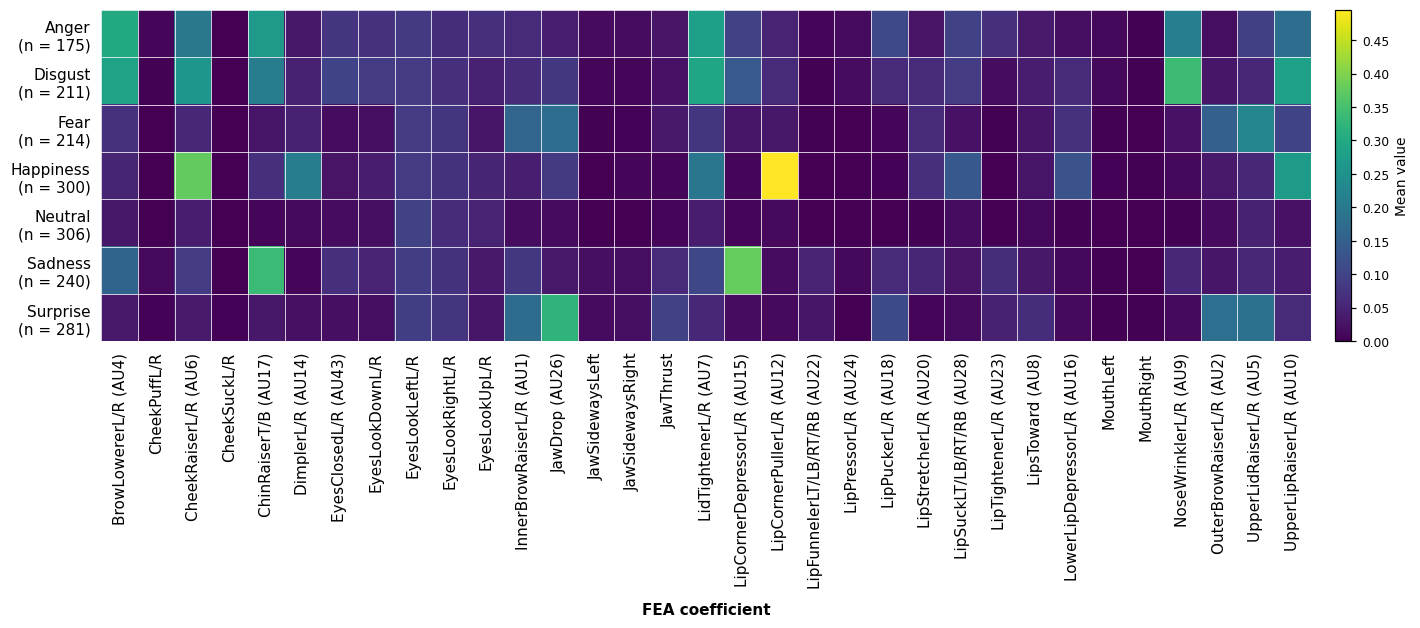

In [13]:
COMPACT_CATEGORY_STYLE = {
    'figsize': (12.8, 5.6),  # Match the reference width; extra height accommodates rotated coefficient names.
    'font_family': 'DejaVu Sans',  # Match the temporal heatmap font.
    'figure_dpi': 110,  # Match the temporal heatmap notebook resolution.
    'save_dpi': 300,  # Resolution of the exported PNG; the PDF keeps vector text.
    'save_pad_inches': 0.02,  # Match the narrow export padding used by the temporal heatmap.
    'facecolor': 'white',  # White figure and axes background.
    'title': '',  # Keep the figure title in the LaTeX caption; enter text for a standalone title.
    'category_row_format': '{category}\n(n = {n})',  # Match the reference two-line category/count labels.
    'title_size': 13,  # Match the reference font size when titles are enabled.
    'title_weight': 'bold',  # Match the optional reference title weight.
    'title_align': 'left',  # Align optional titles to the left.
    'title_pad': 13,  # Space above the heatmap for an optional title, in points.
    'x_label': 'FEA coefficient',  # X-axis title shared by all displayed coefficients.
    'y_label': '',  # Keep the y-axis title in the caption.
    'x_label_size': 10,  # Match the reference x-axis title size.
    'y_label_size': 10,  # Match the reference y-axis title size.
    'label_weight': 'bold',  # Regular axis-label weight, matching the reference.
    'x_label_pad': 9,  # Space between coefficient labels and the x-axis title, in points.
    'y_label_pad': 9,  # Space between row labels and the optional y-axis title, in points.
    'x_tick_size': 10,  # Match the reference tick-label size.
    'y_tick_size': 10,  # Match the reference row-label size.
    'tick_weight': 'normal',  # Regular tick-label weight, matching the reference.
    'x_tick_pad': 7,  # Space between the heatmap and coefficient labels, in points.
    'y_tick_pad': 7,  # Space between the heatmap and row labels, in points.
    'x_tick_rotation': 90,  # Vertical coefficient names keep all explicit group and AU labels readable.
    'cmap': 'viridis',  # Match the reference sequential map.
    'vmin': 0.0,  # Lower color limit in raw coefficient units.
    'vmax': None,  # None uses the displayed maximum; set 1.0 for a fixed full-range scale.
    'show_au_labels': True,  # Append semantic AU codes after the explicit coefficient group names.
    'annotate': False,  # Optionally show coefficient means or deltas; these cells do not encode counts.
    'annotation_size': 9,  # Font size for optional numeric cell annotations.
    'grid_color': 'white',  # Match the reference cell-border color.
    'grid_width': 0.5,  # Match the reference cell-border width in points.
    'show_spines': False,  # Remove outer axes frames, matching the reference.
    'colorbar_label': 'Mean value',  # Colorbar title in the units of the plotted values.
    'colorbar_label_size': 9,  # Match the reference colorbar title size.
    'colorbar_tick_size': 8,  # Match the reference colorbar tick size.
    'colorbar_fraction': 0.035,  # Match the reference colorbar fraction of axes width.
    'colorbar_pad': 0.02,  # Match the reference gap between heatmap and colorbar.
    'colorbar_tick_step': 0.05,  # Automatic ticks; use a positive step such as 0.1 for coefficient values.
}

plot_category_profiles(compact_category_profile[COMPACT_FEATURES], COMPACT_CATEGORY_STYLE,
                       '03_category_profiles_compact', label_map=compact_feature_labels(COMPACT_CATEGORY_STYLE))


### 6.2. Compact confused-minus-correct heatmaps

Three separate one-row panels preserve the exact confusion comparisons. Confusion names appear as row labels, matching the reference's title-free layout; set `confusion_label_position='title'` to restore panel headings. The colorbar identifies the shared **confused − correct** operation.

A diverging colormap remains appropriate for signed deltas: blue indicates decreases and red indicates increases. The reference heatmap's percentage scale does not apply to these raw coefficient differences. `shared_scale=True` makes colors comparable across panels; with `limit=None`, setting it to `False` uses each panel's maximum absolute delta. The displayed groups and numerical values are unchanged.


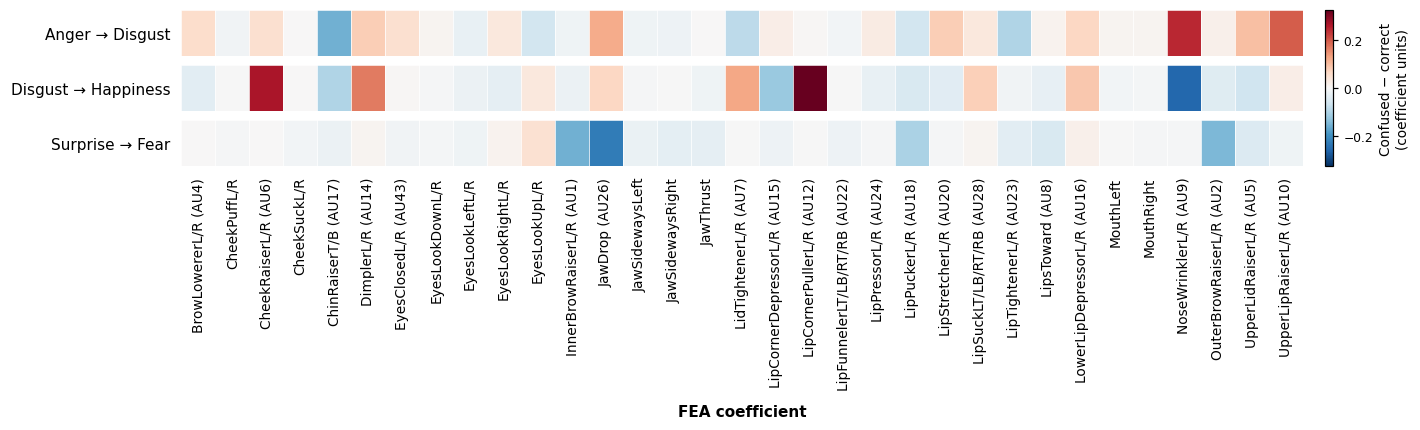

In [14]:
COMPACT_DELTA_STYLE = {
    'figsize': (12.8, 3.8),  # Match the reference width; extra height accommodates rotated coefficient names.
    'font_family': 'DejaVu Sans',  # Match the temporal heatmap font.
    'figure_dpi': 110,  # Match the temporal heatmap notebook resolution.
    'save_dpi': 300,  # Resolution of the exported PNG; the PDF keeps vector text.
    'save_pad_inches': 0.02,  # Match the narrow export padding used by the temporal heatmap.
    'facecolor': 'white',  # White figure and axes background.
    'confusion_label_position': 'row',  # Use row labels like the reference; title restores individual panel headings.
    'title_size': 13,  # Match the reference font size when titles are enabled.
    'title_weight': 'bold',  # Match the optional reference title weight.
    'title_align': 'left',  # Align optional titles to the left.
    'title_pad': 13,  # Space above the heatmap for an optional title, in points.
    'x_label': 'FEA coefficient',  # X-axis title shared by all displayed coefficients.
    'y_label': '',  # Keep the y-axis title in the caption.
    'x_label_size': 10,  # Match the reference x-axis title size.
    'y_label_size': 10,  # Match the reference y-axis title size.
    'label_weight': 'bold',  # Regular axis-label weight, matching the reference.
    'x_label_pad': 9,  # Space between coefficient labels and the x-axis title, in points.
    'y_label_pad': 9,  # Space between row labels and the optional y-axis title, in points.
    'x_tick_size': 9,  # Match the reference tick-label size.
    'y_tick_size': 10,  # Match the reference row-label size.
    'tick_weight': 'normal',  # Regular tick-label weight, matching the reference.
    'x_tick_pad': 7,  # Space between the heatmap and coefficient labels, in points.
    'y_tick_pad': 7,  # Space between the heatmap and row labels, in points.
    'x_tick_rotation': 90,  # Vertical coefficient names keep all explicit group and AU labels readable.
    'cmap': 'RdBu_r',  # Keep a diverging map: red for increases and blue for decreases.
    'limit': None,  # None uses the largest absolute displayed delta; a number fixes symmetric limits.
    'shared_scale': True,  # One scale across the three panels; False enables per-panel automatic maxima.
    'show_au_labels': True,  # Append semantic AU codes after the explicit coefficient group names.
    'annotate': False,  # Optionally show coefficient means or deltas; these cells do not encode counts.
    'annotation_size': 9,  # Font size for optional numeric cell annotations.
    'grid_color': 'white',  # Match the reference cell-border color.
    'grid_width': 0.5,  # Match the reference cell-border width in points.
    'show_spines': False,  # Remove outer axes frames, matching the reference.
    'colorbar_label': 'Confused − correct\n(coefficient units)',  # Colorbar title in the units of the plotted values.
    'colorbar_label_size': 9,  # Match the reference colorbar title size.
    'colorbar_tick_size': 8,  # Match the reference colorbar tick size.
    'colorbar_fraction': 0.035,  # Match the reference colorbar fraction of axes width.
    'colorbar_pad': 0.02,  # Match the reference gap between heatmap and colorbar.
    'colorbar_tick_step': None,  # Automatic ticks; use a positive step such as 0.1 for coefficient values.
}

plot_delta_profiles(compact_delta_profiles[COMPACT_FEATURES], COMPACT_DELTA_STYLE,
                    '04_confused_minus_correct_compact', label_map=compact_feature_labels(COMPACT_DELTA_STYLE))


### 6.3. Numbers matching the compact heatmaps

These rankings use the **same within-sequence averages as the compact figures**, including every defined L/R and top/bottom group. `COMPACT_RANK_DISPLAYED_ONLY=True` restricts candidates to retained columns; setting it to `False` includes all compact groups. This does not mix a group with its individual constituents in the ranking.

Use these tables when discussing the compact figures in the paper. The component table reveals asymmetries or opposing changes hidden by an average. The participant check uses the same weighting and deduplication rules as the baseline analysis.


In [15]:
compact_ranking_measures = COMPACT_FEATURES if COMPACT_RANK_DISPLAYED_ONLY else list(COMPACT_GROUPS)
compact_selected_contrasts = rank_contrasts(compact_contrasts, compact_ranking_measures, COMPACT_TOP_N)
compact_selected_components = selected_components(compact_selected_contrasts, COMPACT_GROUPS)
print(f'Top {COMPACT_TOP_N} compact contrasts per confusion; ranking considers {len(compact_ranking_measures)} groups.')
display_contrasts(compact_selected_contrasts, compact_selected_components)


Top 8 compact contrasts per confusion; ranking considers 33 groups.


rank                feature semantic_facs_code  correct_mean  confused_mean  delta_raw  relative_change_percent  shared_participant_delta  sign_reversal  \
source   target                                                                                                                                                                
Anger    Disgust       1        NoseWrinklerL/R                AU9        0.1439         0.3887     0.2448                 170.1670                    0.0201          False   
         Disgust       2      UpperLipRaiserL/R               AU10        0.1733         0.3719     0.1986                 114.5909                    0.0153          False   
         Disgust       3          ChinRaiserT/B               AU17        0.3529         0.1953    -0.1576                 -44.6594                   -0.1107          False   
         Disgust       4                JawDrop               AU26        0.0200         0.1416     0.1216                 606.7207                    0.0093          False   
         Disgust       5        LipTightenerL/R               AU23        0.1160         0.0169    -0.0991                 -85.4708                    0.0112           True   
         Disgust       6      UpperLidRaiserL/R                AU5        0.0972         0.1945     0.0972                  99.9543                    0.0366          False   
         Disgust       7        LidTightenerL/R                AU7        0.3644         0.2799    -0.0844                 -23.1698                   -0.0212          False   
         Disgust       8        LipStretcherL/R               AU20        0.0125         0.0921     0.0796                 636.7688                    0.0062          False   
Disgust  Happiness     1     LipCornerPullerL/R               AU12        0.0710         0.3974     0.3264                 459.4986                    0.2268          False   
         Happiness     2         CheekRaiserL/R                AU6        0.2534         0.5195     0.2661                 105.0344                    0.0930          False   
         Happiness     3        NoseWrinklerL/R                AU9        0.3276         0.0717    -0.2559                 -78.1192                   -0.1560          False   
         Happiness     4             DimplerL/R               AU14        0.0797         0.2481     0.1684                 211.2555                    0.1402          False   
         Happiness     5        LidTightenerL/R                AU7        0.2844         0.4095     0.1251                  43.9898                    0.1656          False   
         Happiness     6  LipCornerDepressorL/R               AU15        0.1322         0.0103    -0.1219                 -92.1990                   -0.0201          False   
         Happiness     7          ChinRaiserT/B               AU17        0.1602         0.0620    -0.0982                 -61.2883                   -0.1539          False   
         Happiness     8   LowerLipDepressorL/R               AU16        0.1112         0.1986     0.0874                  78.5644                    0.1197          False   
Surprise Fear          1                JawDrop               AU26        0.4362         0.2075    -0.2287                 -52.4323                   -0.0597          False   
         Fear          2     InnerBrowRaiserL/R                AU1        0.3269         0.1706    -0.1563                 -47.8130                   -0.0738          False   
         Fear          3     OuterBrowRaiserL/R                AU2        0.3332         0.1864    -0.1468                 -44.0579                   -0.0805          False   
         Fear          4           LipPuckerL/R               AU18        0.1286         0.0256    -0.1030                 -80.0668                   -0.1033          False   
         Fear          5          EyesLookUpL/R              EYE63        0.0368         0.0875     0.0506                 137.3584                 

rank       selected_measure              feature  correct_mean  confused_mean  delta_raw  relative_change_percent
source   target                                                                                                                      
Anger    Disgust       1        NoseWrinklerL/R        NoseWrinklerL        0.1443         0.3873     0.2430                 168.3753
         Disgust       1        NoseWrinklerL/R        NoseWrinklerR        0.1434         0.3901     0.2467                 171.9693
         Disgust       2      UpperLipRaiserL/R      UpperLipRaiserL        0.1671         0.3611     0.1940                 116.1078
         Disgust       2      UpperLipRaiserL/R      UpperLipRaiserR        0.1795         0.3826     0.2031                 113.1788
         Disgust       3          ChinRaiserT/B          ChinRaiserB        0.3490         0.1566    -0.1924                 -55.1269
         Disgust       3          ChinRaiserT/B          ChinRaiserT        0.3568         0.2340    -0.1228                 -34.4207
         Disgust       4                JawDrop              JawDrop        0.0200         0.1416     0.1216                 606.7207
         Disgust       5        LipTightenerL/R        LipTightenerL        0.1171         0.0178    -0.0993                 -84.8030
         Disgust       5        LipTightenerL/R        LipTightenerR        0.1149         0.0159    -0.0990                 -86.1510
         Disgust       6      UpperLidRaiserL/R      UpperLidRaiserL        0.0900         0.1712     0.0811                  90.1454
         Disgust       6      UpperLidRaiserL/R      UpperLidRaiserR        0.1045         0.2177     0.1133                 108.4052
         Disgust       7        LidTightenerL/R        LidTightenerL        0.3676         0.2563    -0.1113                 -30.2796
         Disgust       7        LidTightenerL/R        LidTightenerR        0.3611         0.3036    -0.0575                 -15.9330
         Disgust       8        LipStretcherL/R        LipStretcherL        0.0129         0.0899     0.0770                 597.6567
         Disgust       8        LipStretcherL/R        LipStretcherR        0.0121         0.0944     0.0822                 678.3203
Disgust  Happiness     1     LipCornerPullerL/R     LipCornerPullerL        0.0706         0.3948     0.3241                 458.8386
         Happiness     1     LipCornerPullerL/R     LipCornerPullerR        0.0714         0.4001     0.3287                 460.1513
         Happiness     2         CheekRaiserL/R         CheekRaiserL        0.2682         0.5309     0.2627                  97.9257
         Happiness     2         CheekRaiserL/R         CheekRaiserR        0.2385         0.5080     0.2695                 113.0309
         Happiness     3        NoseWrinklerL/R        NoseWrinklerL        0.3257         0.0781    -0.2477                 -76.0294
         Happiness     3        NoseWrinklerL/R        NoseWrinklerR        0.3294         0.0653    -0.2641                 -80.1856
         Happiness     4             DimplerL/R             DimplerL        0.0795         0.2499     0.1704                 214.1923
         Happiness     4             DimplerL/R             DimplerR        0.0799         0.2463     0.1664                 208.3315
         Happiness     5        LidTightenerL/R        LidTightenerL        0.2901         0.4178     0.1277                  44.0270
         Happiness     5        LidTightenerL/R        LidTightenerR        0.2787         0.4012     0.1225                  43.9511
         Happiness     6  LipCornerDepressorL/R  LipCornerDepressorL        0.1432         0.0159    -0.1273                 -88.8958
         Happiness     6  LipCornerDepressorL/R  LipCornerDepressorR        0.1213         0.0047    -0.1165                 -96.0998
         Happiness     7          ChinRaiserT/B          ChinRaiserB        0.1258         0.0217    -0.1041                 -82.7626


Caution: Anger → Disgust, LipTightenerL/R: pooled Δ=-0.099, shared-participant Δ=+0.011 (6 participants).
Caution: Surprise → Fear, EyesLookUpL/R: pooled Δ=+0.051, shared-participant Δ=-0.015 (5 participants).


## 7. Save selected tables

`SAVE_TABLES=True` writes only group counts, the baseline selected contrasts, the compact selected contrasts, and their constituent-channel results. Complete intermediate tables remain in memory. Figures are saved by their own cells when `SAVE_FIGURES=True`. Matching output filenames are overwritten on rerun.


In [16]:
if SAVE_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    group_counts.to_csv(OUTPUT_DIR / 'confusion_group_counts.csv', index=False)
    selected_contrasts[['source', 'target', *result_columns]].to_csv(OUTPUT_DIR / 'selected_contrasts.csv', index=False)
    compact_selected_contrasts[['source', 'target', *result_columns, 'channels_averaged']].to_csv(
        OUTPUT_DIR / 'compact_selected_contrasts.csv', index=False)
    compact_selected_components[['source', 'target', *component_columns]].to_csv(
        OUTPUT_DIR / 'compact_selected_components.csv', index=False)
if SAVE_FIGURES or SAVE_TABLES:
    print('Saved outputs:', OUTPUT_DIR)


Saved outputs: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis_2/outputs/section_6_3_focused


## 8. Export the Markdown results report

Run this cell last. The report is generated from current results and contains a brief overview, analysis settings and definitions, all 21 category-pair distances, top-coefficient overlap and rankings, compact contrasts and their components, baseline contrasts, figure links and actual color limits, grouping decisions, and input provenance. The compact results are the primary numerical companion to the compact figures.

The report is written to `section_6_3_summary.md` beside the figures, independently of `SAVE_TABLES`. After changing analysis settings, run all cells to avoid mixing stale figures with new results. Keep the report and exported figures together for working relative links.

**Interpretation:** category-profile proximity provides context for confusion patterns, while selected coefficient differences describe the observed errors. Neither establishes a cause of model predictions. These analyses compare averages, and participant coverage and sensitivity-check reversals constrain generalization.

**Supplement placement:** the compact PDFs are `03_category_profiles_compact.pdf` and `04_confused_minus_correct_compact.pdf`. Copy them from the output directory to the supplement's `assets/` directory and include each with `width=\textwidth`. The plot titles and explanatory notes belong in the captions. Describe category profiles as raw means of sequence means, state the selected splits and equal constituent averaging, and describe deltas as view-weighted confused minus correct with a shared symmetric scale when enabled. State any active grouping filter. Run all cells to regenerate the styled PDFs and the report.


In [17]:
from datetime import datetime, timezone
import hashlib


def markdown_table(frame):
    """Render tables without the optional tabulate dependency; preserve small distances."""
    def format_value(value):
        if pd.isna(value):
            return 'NA'
        if isinstance(value, (bool, np.bool_)):
            return 'yes' if value else 'no'
        if isinstance(value, (float, np.floating)):
            return f'{value:.5f}'
        return str(value).replace('|', r'\|').replace('\n', ' ')
    header = '| ' + ' | '.join(map(str, frame.columns)) + ' |'
    divider = '| ' + ' | '.join(['---'] * len(frame.columns)) + ' |'
    rows = ['| ' + ' | '.join(format_value(value) for value in row) + ' |' for row in frame.itertuples(index=False, name=None)]
    return '\n'.join([header, divider, *rows])


summary_lines = ['# Section 6.3 — FEA analysis results', '', f'Generated (UTC): {datetime.now(timezone.utc).isoformat()}', '']


def add_section(title, text=None, table=None, level=2):
    summary_lines.extend([f'{"#" * level} {title}', ''])
    if text:
        summary_lines.extend([text, ''])
    if table is not None:
        summary_lines.extend([markdown_table(table), ''])


def add_contrast_tables(selected, components, component_mapping):
    for source, target in CONFUSIONS:
        rows = selected.loc[selected['source'].eq(source) & selected['target'].eq(target)]
        add_section(f'{source} → {target}', table=rows[result_columns], level=3)
        averaged = {name for name, channels in component_mapping.items() if len(channels) > 1}
        details = components.loc[components['source'].eq(source) & components['target'].eq(target)
                                 & components['selected_measure'].isin(averaged)]
        if not details.empty:
            summary_lines.extend(['Constituent channels behind selected averages:', '', markdown_table(details[component_columns]), ''])


accuracy = test['true_label'].eq(test['multimodal_pred']).mean()
error_count = int(test['true_label'].ne(test['multimodal_pred']).sum())
selected_error_count = int(group_counts['confused_views'].sum())
rank_description = 'absolute delta' if RANK_ABSOLUTE_DELTA else 'signed delta (largest increases first)'
filter_description = 'disabled; all groups retained' if MIN_CATEGORY_MEAN is None else f'maximum category mean > {MIN_CATEGORY_MEAN:g}'
key_findings = [
    f'- Multimodal test accuracy: **{correct_count}/{len(test)} ({100 * accuracy:.2f}%)**; '
    f"{test['reenactment_id'].nunique()} reenactments, {test['participant_id'].nunique()} participants.",
    f'- The selected confusions cover **{selected_error_count}/{error_count} errors ({100 * selected_error_count / error_count:.1f}%)** at the view level.',
    f"- Category profiles: **{len(category_data)} reenactments, {category_data['participant_id'].nunique()} participants**, using {', '.join(CATEGORY_SPLITS)}.",
]
for row in category_pair_ranking.head(2).itertuples():
    key_findings.append(f'- Category-profile similarity rank **{row.rank}/{len(category_pair_ranking)}: {row.first_category} / {row.second_category}**, '
                        f'mean absolute difference **{row.mean_absolute_difference:.5f}** across all 63 raw coefficients (lower is more similar).')
for row in overlap_summary.itertuples():
    key_findings.append(f'- **{row.pair}, top {row.top_n}: {row.shared_count}/{row.top_n} shared** ({row.overlap_percent:.1f}%); '
                        f"{'identical' if row.identical_sets else 'different'} coefficient sets.")
key_findings.append(f'- Compact figures: **{len(FEA_COLUMNS)} channels → {len(COMPACT_GROUPS)} groups → {len(COMPACT_FEATURES)} displayed columns**; '
                    f'mean filter {filter_description}; AU exemption={KEEP_ALL_AU_GROUPS}.')
for row in compact_selected_contrasts.loc[compact_selected_contrasts['rank'].eq(1)].itertuples():
    label = f'{row.feature} ({row.semantic_facs_code})' if row.semantic_facs_code.startswith('AU') else row.feature
    key_findings.append(f'- Highest-ranked compact contrast, **{row.source} → {row.target}: {label}**, '
                        f'{row.confused_mean:.4f} confused vs {row.correct_mean:.4f} correct; **Δ={row.delta_raw:+.4f}** coefficient units.')
compact_reversals = compact_selected_contrasts.loc[compact_selected_contrasts['sign_reversal'].fillna(False)]
reversal_names = '; '.join(f'{row.source} → {row.target}: {row.feature}' for row in compact_reversals.itertuples())
key_findings.append('- Shared-participant sign reversals among selected compact contrasts: **' + (reversal_names or 'none') + '**.')
add_section('1. Results at a glance', '\n'.join(key_findings))

add_section('2. Scope, settings, and units', '\n'.join([
    '- Sequence means average each channel over 30 steps. Category means weight reenactments equally; no standardization or Neutral centering.',
    '- Error analyses use test-only multimodal predictions (`multimodal_pred`), weighting each camera-view prediction equally.',
    '- Correct = true source predicted as source; confused = true source predicted as the named target. Other errors are excluded.',
    '- Two views share an FEA sequence. A reenactment may occur twice in one group or in both groups; observations are dependent.',
    '- `delta_raw` = confused mean − correct mean, in coefficient units. Positive = higher in confused cases; negative = lower.',
    f'- Relative change (%) = 100 × delta_raw / correct mean; NA indicates a baseline below {MIN_RELATIVE_BASELINE:g}. This is not a percentage-point difference.',
    '- The shared-participant check deduplicates reenactments within each group, calculates participant means, and weights shared participants equally.',
    '- `sign_reversal=yes` means pooled and shared-participant deltas have opposite signs. NA indicates an unavailable check.',
    f'- Baseline ranking: top {TOP_N} by {rank_description}; RANK_BILATERAL={RANK_BILATERAL} (the original 10 bilateral pairs).',
    f'- Compact ranking: top {COMPACT_TOP_N} by {rank_description}; displayed groups only={COMPACT_RANK_DISPLAYED_ONLY}; '
    f'{len(compact_ranking_measures)} eligible groups. Exact ranking ties resolve alphabetically.',
    f'- Category top coefficients: {CATEGORY_TOP_N}; overlap cutoffs: {sorted({CATEGORY_TOP_N, OVERLAP_TOP_N})}; all 63 raw channels, independent of figure selection.',
    '- Compact groups average their constituents equally within each sequence; grouping and filtering never affect the raw 63-channel similarity analysis.',
]))
add_section('Dataset counts', 'Unique reenactments by split, not camera views.', class_counts.rename_axis('Category').reset_index(), level=3)
add_section('Confusion group coverage', 'Reenactment overlap can occur when the two camera views receive different predictions.', group_counts, level=3)

add_section('3. Pairwise similarity of raw category profiles',
            'For each pair (a, b), distance = mean over all 63 channels of abs(category_mean[a] − category_mean[b]). '
            'Lower values mean more similar category-average profiles. All channels have equal weight; left/right channels remain separate. '
            'This is a distance between means, not the average distance between individual samples, and does not describe within-class variation.',
            category_pair_ranking)
if INSPECT_PAIR is not None:
    add_section(f'Largest coefficient differences: {INSPECT_PAIR[0]} / {INSPECT_PAIR[1]}',
                'The signed difference is second_category − first_category, following the table columns; ranking uses its absolute value.',
                pair_details.head(N_COEFFICIENTS_TO_SHOW), level=3)

add_section('4. Top-coefficient overlap and category rankings',
            'Overlap (%) = intersection size / cutoff × 100; Jaccard (%) = intersection size / union size × 100. '
            'Identical sets ignore order; identical order also requires matching ranks. Shared membership does not imply equal coefficient values.',
            overlap_summary)
for category in CLASSES:
    rows = top_fea_by_category.loc[top_fea_by_category['category'].eq(category), ['rank', 'feature', 'mean_sequence_mean']]
    add_section(f'{category}: top {CATEGORY_TOP_N}', 'High raw means do not establish discriminative importance.', rows, level=3)

add_section('5. Compact contrasts — numerical companion to the compact figures',
            f'Top {COMPACT_TOP_N} per confusion by {rank_description}, using the same within-sequence averages as the compact heatmaps. '
            'The component tables expose changes concealed by averaging. The participant check is descriptive; no significance tests are implied.')
add_contrast_tables(compact_selected_contrasts, compact_selected_components, COMPACT_GROUPS)

add_section('6. Compact grouping and retention', '\n'.join([
    f'- Filter: {filter_description}; evaluated using {", ".join(CATEGORY_SPLITS)}.',
    f'- KEEP_ALL_AU_GROUPS={KEEP_ALL_AU_GROUPS}: ' + ('AU groups bypass an active threshold.' if KEEP_ALL_AU_GROUPS else 'an active threshold applies to every group.'),
    '- Only AU-prefixed codes qualify for exemption; AD and eye-position codes do not. Exemption is independent of showing AU labels.',
    '- LipFunnelerLT/LB/RT/RB and LipSuckLT/LB/RT/RB average four explicit components; ChinRaiserT/B averages two. Opposing directions stay separate.',
    '- Both compact figures use the same retained groups in the same order. A low category mean does not prove a movement is uninformative for errors.',
    '- Removed groups: ' + (', '.join(compact_mapping.loc[~compact_mapping['retained'], 'group']) or 'none') + '.',
]), compact_mapping)

add_section('7. Figures and actual color scales',
            'Links are relative to this report; keep report and figures together. Category figures show raw means; delta figures show confused − correct. '
            'Compact captions should state equal constituent averaging, selected category splits, the mean-filter threshold, and AU exemption mode. '
            'The compact figures use the temporal heatmap typography and 12.8-inch source width for textwidth LaTeX placement; '
            'additional height accommodates vertical group labels. Compact category titles are omitted and confusion names use row labels by default. '
            'Colors retain their coefficient units: sequential means and signed diverging deltas, not percentages.')
for title, stem in [
    ('Raw category profiles', '01_category_profiles_raw'),
    ('Raw confused-minus-correct profiles', '02_confused_minus_correct'),
    ('Compact raw category profiles', '03_category_profiles_compact'),
    ('Compact confused-minus-correct profiles', '04_confused_minus_correct_compact'),
]:
    record = figure_records[stem]
    limits = '; '.join(f'[{low:.5f}, {high:.5f}]' for low, high in record['limits'])
    add_section(title, f"Columns: {len(record['features'])}; colormap: {record['cmap']}; actual color limits (panel order): {limits}.\n\n"
                + 'Displayed coefficients: ' + ', '.join(record['features']) + '.', level=3)
    if record['saved'] and all((OUTPUT_DIR / f'{stem}.{extension}').is_file() for extension in ['png', 'pdf']):
        summary_lines.extend([f'![{title}]({stem}.png)', '', f'[PDF figure]({stem}.pdf)', ''])
    else:
        summary_lines.extend(['Figure files not linked: rerun this figure with SAVE_FIGURES=True.', ''])

add_section('8. Baseline contrasts — original partial bilateral grouping',
            'These preserve the earlier ranking settings. When RANK_BILATERAL=True, only the original 10 L/R pairs replace their components; '
            'other channels remain individual. Use Section 5 for numbers matching the compact figures.')
add_contrast_tables(selected_contrasts, selected_channels, BILATERAL)

add_section('9. Interpretation and Section 6.3 coverage', '\n'.join([
    '- Profile proximity provides context for confusion patterns; individual coefficient contrasts describe the observed error groups. Neither establishes causation.',
    '- Proprietary FEA coefficients are not validated AU measurements, muscle activity, or emotional ground truth. FACS identifiers are semantic crosswalk labels.',
    '- These associations do not establish model feature reliance or that a benchmark label is incorrect.',
    '- Small participant counts, repeated views, and shared-participant sign reversals constrain generalization. Largest exploratory differences are not necessarily significant.',
    '- Similarity rankings concern category averages and depend on this raw, equally weighted 63-channel representation; shared low-valued channels can contribute to closeness.',
    '- Correctly classified target-category cases are not part of the confusion contrasts; proximity to those cases is not tested.',
    '- Human agreement, class-standardized accuracy by agreement, and dissenting-label correspondence remain in analysis 06 and are not recomputed here.',
]))

input_rows = []
input_paths = [PREDICTION_CSV, *[DFEA_DIR / name for name in SPLIT_FILES.values()],
               REPO_ROOT / '6_discussion/fea_analysis/data/facs_fea_mapping.json']
for path in input_paths:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    input_rows.append({'file': path.name, 'path': str(path.resolve()), 'sha256': digest.hexdigest()})
add_section('10. Input provenance and outputs',
            'Generated from the current kernel results. Rerun all cells after changing inputs or analysis settings. '
            f'SAVE_FIGURES={SAVE_FIGURES}; SAVE_TABLES={SAVE_TABLES}; the Markdown report is always exported. '
            'The optional CSVs are confusion_group_counts.csv, selected_contrasts.csv, compact_selected_contrasts.csv, and compact_selected_components.csv.',
            pd.DataFrame(input_rows))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary_path = OUTPUT_DIR / SUMMARY_FILENAME
summary_path.write_text('\n'.join(summary_lines).rstrip() + '\n', encoding='utf-8')
print(f'Markdown report saved to: {summary_path}')


Markdown report saved to: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis_2/outputs/section_6_3_focused/section_6_3_summary.md
